In [1]:
!pip install statsmodels

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pandas.plotting import autocorrelation_plot
from statsmodels.tsa.seasonal import seasonal_decompose

## **Collecting Data + Preprocessing Data**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

df_store = pd.read_csv('/content/drive/MyDrive/python/store5_3.csv')
df_store

Mounted at /content/drive


,id,date,store_nbr,family,sales,onpromotion,dcoilwtico
0,1452,2013-01-01,5,AUTOMOTIVE,0.000,0,NaN
1,1453,2013-01-01,5,BABY CARE,0.000,0,NaN
2,1454,2013-01-01,5,BEAUTY,0.000,0,NaN
3,1455,2013-01-01,5,BEVERAGES,0.000,0,NaN
4,1456,2013-01-01,5,BOOKS,0.000,0,NaN
...,...,...,...,...,...,...,...
55567,3000586,2017-08-15,5,POULTRY,241.011,1,47.57
55568,3000587,2017-08-15,5,PREPARED FOODS,52.121,0,47.57
55569,3000588,2017-08-15,5,PRODUCE,1357.823,4,47.57
55570,3000589,2017-08-15,5,SCHOOL AND OFFICE SUPPLIES,0.000,0,47.57


count jumlah store_nbr

In [4]:
df_store['store_nbr'].value_counts()

,count
store_nbr,
5,55572


In [5]:
df_store.value_counts()

,,,,,,,count
id,date,store_nbr,family,sales,onpromotion,dcoilwtico,
3234,2013-01-02,5,AUTOMOTIVE,6.000,0,93.14,1
2002643,2016-02-01,5,BREAD/BAKERY,387.566,0,31.62,1
2002645,2016-02-01,5,CLEANING,1224.000,6,31.62,1
2002646,2016-02-01,5,DAIRY,518.000,0,31.62,1
2002647,2016-02-01,5,DELI,310.804,1,31.62,1
...,...,...,...,...,...,...,...
1001176,2014-07-17,5,"LIQUOR,WINE,BEER",54.000,0,103.84,1
1001177,2014-07-17,5,MAGAZINES,4.000,0,103.84,1
1001178,2014-07-17,5,MEATS,276.543,0,103.84,1


In [6]:
df_store.count()

,0
id,55572
date,55572
store_nbr,55572
family,55572
sales,55572
onpromotion,55572
dcoilwtico,38379


In [7]:
df_store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55572 entries, 0 to 55571
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           55572 non-null  int64  
 1   date         55572 non-null  object 
 2   store_nbr    55572 non-null  int64  
 3   family       55572 non-null  object 
 4   sales        55572 non-null  float64
 5   onpromotion  55572 non-null  int64  
 6   dcoilwtico   38379 non-null  float64
dtypes: float64(2), int64(3), object(2)
memory usage: 3.0+ MB


ubah tipe data untuk date menjadi datetime karena pengolahan data time series

In [8]:
df_store['date'] = pd.to_datetime(df_store['date']) #mengubah tipe data dari object menjadi datestamp
df_store.info()
df_store

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55572 entries, 0 to 55571
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id           55572 non-null  int64         
 1   date         55572 non-null  datetime64[ns]
 2   store_nbr    55572 non-null  int64         
 3   family       55572 non-null  object        
 4   sales        55572 non-null  float64       
 5   onpromotion  55572 non-null  int64         
 6   dcoilwtico   38379 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(1)
memory usage: 3.0+ MB


,id,date,store_nbr,family,sales,onpromotion,dcoilwtico
0,1452,2013-01-01,5,AUTOMOTIVE,0.000,0,NaN
1,1453,2013-01-01,5,BABY CARE,0.000,0,NaN
2,1454,2013-01-01,5,BEAUTY,0.000,0,NaN
3,1455,2013-01-01,5,BEVERAGES,0.000,0,NaN
4,1456,2013-01-01,5,BOOKS,0.000,0,NaN
...,...,...,...,...,...,...,...
55567,3000586,2017-08-15,5,POULTRY,241.011,1,47.57
55568,3000587,2017-08-15,5,PREPARED FOODS,52.121,0,47.57
55569,3000588,2017-08-15,5,PRODUCE,1357.823,4,47.57
55570,3000589,2017-08-15,5,SCHOOL AND OFFICE SUPPLIES,0.000,0,47.57


Pilih Atribut Family berdasarkan Sales terbesar
Chose_Atribut_Family_BasedOn Big_Sales

In [9]:
df_store['family'].value_counts()

,count
family,
AUTOMOTIVE,1684
HOME APPLIANCES,1684
SCHOOL AND OFFICE SUPPLIES,1684
PRODUCE,1684
PREPARED FOODS,1684
POULTRY,1684
PLAYERS AND ELECTRONICS,1684
PET SUPPLIES,1684
PERSONAL CARE,1684


atribut yang dipilih untuk forecast adalah atribut family dengan sales terbesar, o.k.i perlu melihat semua atribut family berdasarkan sales

In [10]:
sales_per_family = df_store.groupby('family')['sales'].sum().reset_index()
sales_per_family

,family,sales
0,AUTOMOTIVE,9.194000e+03
1,BABY CARE,2.150000e+02
2,BEAUTY,8.684000e+03
3,BEVERAGES,2.533831e+06
4,BOOKS,2.300000e+02
5,BREAD/BAKERY,6.428546e+05
6,CELEBRATION,2.617600e+04
7,CLEANING,1.667748e+06
8,DAIRY,8.712830e+05
9,DELI,4.152710e+05


mengurutkan semua atribut family berdasarkan sales

In [11]:
sales_per_family_sorted = sales_per_family.sort_values(by='sales', ascending=False)
sales_per_family_sorted

,family,sales
12,GROCERY I,5.262682e+06
3,BEVERAGES,2.533831e+06
7,CLEANING,1.667748e+06
30,PRODUCE,1.653582e+06
8,DAIRY,8.712830e+05
5,BREAD/BAKERY,6.428546e+05
24,MEATS,4.771044e+05
25,PERSONAL CARE,4.501660e+05
28,POULTRY,4.196304e+05
9,DELI,4.152710e+05


mengurutkan semua atribut family berdasarkan sales, 3 besar

In [12]:
top_3_families = sales_per_family_sorted.head(3)
top_3_families

,family,sales
12,GROCERY I,5262681.658
3,BEVERAGES,2533831.000
7,CLEANING,1667748.000


atribut family berdasarkan sales, 5 besar: 'GROCERY I','BEVERAGES','CLEANING

# **Atribut family berdasarkan sales: 'GROCERY I'**

# Checking Missing Value

Checking Missing Value All Atribut

In [13]:
df_store.isna().value_counts()

id     date   store_nbr  family  sales  onpromotion  dcoilwtico
False  False  False      False   False  False        False         38379
                                                     True          17193
Name: count, dtype: int64

atribut dcoilwtico: terdapat 17193 baris yang missing value

record yang memiliki nilai kosong pada atribut dcoilwtico

In [14]:
df_store_dcoilwtico_na = df_store['dcoilwtico'].isnull().sum()
print(f"\nJumlah record dengan 'dcoilwtico' kosong: {df_store_dcoilwtico_na}")


Jumlah record dengan 'dcoilwtico' kosong: 17193


In [15]:
df_store_dcoilwtico_record_kosong = df_store[df_store['dcoilwtico'].isnull()]
print("\nRecord dengan 'dcoilwtico' kosong:")
print(df_store_dcoilwtico_record_kosong)


Record dengan 'dcoilwtico' kosong:
            id       date  store_nbr                      family     sales  \
0         1452 2013-01-01          5                  AUTOMOTIVE     0.000   
1         1453 2013-01-01          5                   BABY CARE     0.000   
2         1454 2013-01-01          5                      BEAUTY     0.000   
3         1455 2013-01-01          5                   BEVERAGES     0.000   
4         1456 2013-01-01          5                       BOOKS     0.000   
...        ...        ...        ...                         ...       ...   
55501  2997022 2017-08-13          5                     POULTRY   232.897   
55502  2997023 2017-08-13          5              PREPARED FOODS    65.945   
55503  2997024 2017-08-13          5                     PRODUCE  1487.221   
55504  2997025 2017-08-13          5  SCHOOL AND OFFICE SUPPLIES     1.000   
55505  2997026 2017-08-13          5                     SEAFOOD    11.642   

       onpromotion  dcoilwt

statistik deskripsi

In [16]:
df_store.describe()

,id,date,store_nbr,sales,onpromotion,dcoilwtico
count,5.557200e+04,55572,55572.0,55572.000000,55572.000000,38379.000000
mean,1.501021e+06,2015-04-24 08:27:04.703088128,5.0,280.580231,2.687864,67.925589
min,1.452000e+03,2013-01-01 00:00:00,5.0,0.000000,0.000000,26.190000
25%,7.512365e+05,2014-02-26 18:00:00,5.0,1.000000,0.000000,46.380000
50%,1.501021e+06,2015-04-24 12:00:00,5.0,19.000000,0.000000,53.330000
75%,2.250806e+06,2016-06-19 06:00:00,5.0,237.000000,0.000000,95.800000
max,3.000590e+06,2017-08-15 00:00:00,5.0,8216.620000,182.000000,110.620000
std,8.662894e+05,NaN,0.0,652.588149,11.748996,25.666659


terdapat atribut dcoilwtico 17.193 baris yang missing value

Isi yang kosong pada atribut dcoilwtico_interpolasi dengan metode interpolasi

buat atribut baru 'dcoilwtico_interpolate'

In [17]:
df_store['dcoilwtico_interpolate'] = df_store['dcoilwtico']
df_store

,id,date,store_nbr,family,sales,onpromotion,dcoilwtico,dcoilwtico_interpolate
0,1452,2013-01-01,5,AUTOMOTIVE,0.000,0,NaN,NaN
1,1453,2013-01-01,5,BABY CARE,0.000,0,NaN,NaN
2,1454,2013-01-01,5,BEAUTY,0.000,0,NaN,NaN
3,1455,2013-01-01,5,BEVERAGES,0.000,0,NaN,NaN
4,1456,2013-01-01,5,BOOKS,0.000,0,NaN,NaN
...,...,...,...,...,...,...,...,...
55567,3000586,2017-08-15,5,POULTRY,241.011,1,47.57,47.57
55568,3000587,2017-08-15,5,PREPARED FOODS,52.121,0,47.57,47.57
55569,3000588,2017-08-15,5,PRODUCE,1357.823,4,47.57,47.57
55570,3000589,2017-08-15,5,SCHOOL AND OFFICE SUPPLIES,0.000,0,47.57,47.57


metode yang digunakan untuk mengisi missing value: metode polynomial order 2

In [18]:
df_store['dcoilwtico_interpolate'] = df_store['dcoilwtico'].interpolate(method='polynomial', order=2)
df_store['dcoilwtico_interpolate'].fillna(method='ffill', inplace=True)
df_store.head()

<ipython-input-18-69fc9f100223>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_store['dcoilwtico_interpolate'].fillna(method='ffill', inplace=True)
<ipython-input-18-69fc9f100223>:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_store['dcoilwtico_interpolate'].fillna(method='ffill', inplace=True)


,id,date,store_nbr,family,sales,onpromotion,dcoilwtico,dcoilwtico_interpolate
0,1452,2013-01-01,5,AUTOMOTIVE,0.0,0,NaN,NaN
1,1453,2013-01-01,5,BABY CARE,0.0,0,NaN,NaN
2,1454,2013-01-01,5,BEAUTY,0.0,0,NaN,NaN
3,1455,2013-01-01,5,BEVERAGES,0.0,0,NaN,NaN
4,1456,2013-01-01,5,BOOKS,0.0,0,NaN,NaN


Cek apakah masih ada NaN setelah interpolasi

In [19]:
print(df_store.isna().sum())

id                            0
date                          0
store_nbr                     0
family                        0
sales                         0
onpromotion                   0
dcoilwtico                17193
dcoilwtico_interpolate       33
dtype: int64


ternyata masih ada 33 record, solusi d interpolasikembali dengan metode backward maupun foward

In [20]:
df_store['dcoilwtico_interpolate'].fillna(method='ffill', inplace=True)
df_store['dcoilwtico_interpolate'].fillna(method='bfill', inplace=True)

<ipython-input-20-d84fe0c43ca7>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_store['dcoilwtico_interpolate'].fillna(method='ffill', inplace=True)
<ipython-input-20-d84fe0c43ca7>:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_store['dcoilwtico_interpolate'].fillna(method='ffill', inplace=True)
<ipython-input-20-d84fe0c43ca7>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignme

Cek kembali apakah masih ada NaN setelah interpolasi

In [21]:
print(df_store.isna().sum())

id                            0
date                          0
store_nbr                     0
family                        0
sales                         0
onpromotion                   0
dcoilwtico                17193
dcoilwtico_interpolate        0
dtype: int64


Membuat plot perbandingan sebelum dan sesudah interpolasi

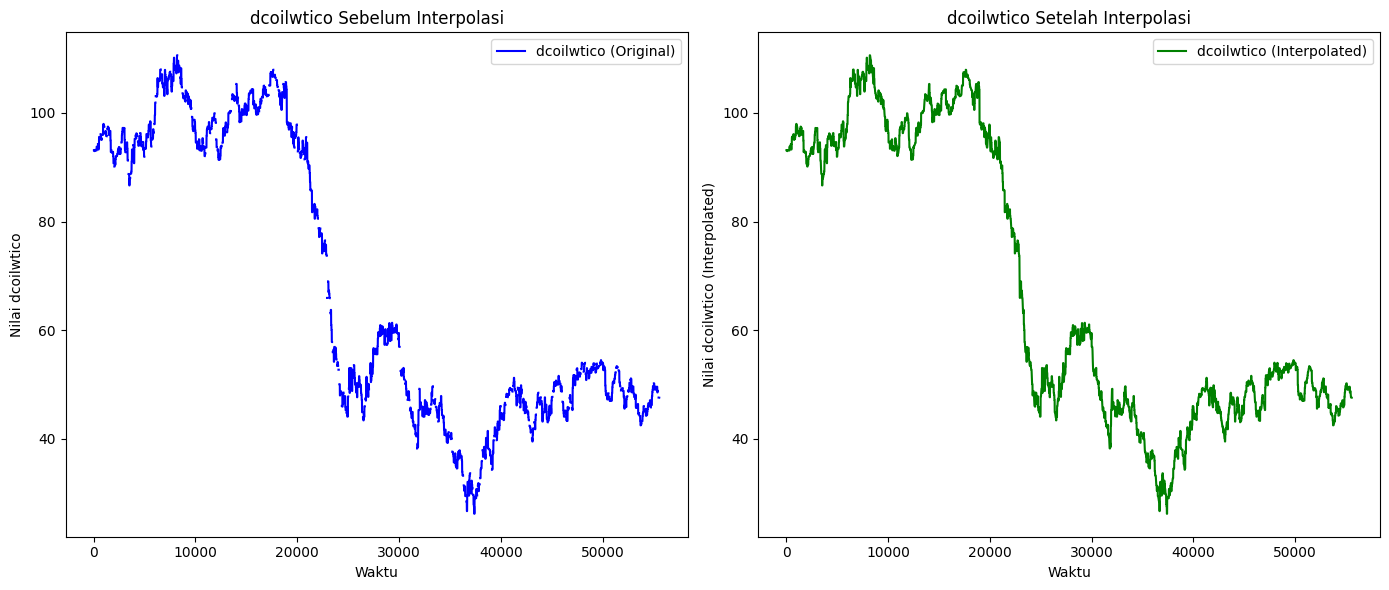

In [22]:
import matplotlib.pyplot as plt

# Membuat plot perbandingan sebelum dan sesudah interpolasi
plt.figure(figsize=(14, 6))

# Plot dcoilwtico sebelum interpolasi
plt.subplot(1, 2, 1)
plt.plot(df_store['dcoilwtico'], label='dcoilwtico (Original)', color='blue')
plt.title('dcoilwtico Sebelum Interpolasi')
plt.xlabel('Waktu')
plt.ylabel('Nilai dcoilwtico')
plt.legend()

# Plot dcoilwtico setelah fill mean
plt.subplot(1, 2, 2)
plt.plot(df_store['dcoilwtico_interpolate'], label='dcoilwtico (Interpolated)', color='green')
plt.title('dcoilwtico Setelah Interpolasi')
plt.xlabel('Waktu')
plt.ylabel('Nilai dcoilwtico (Interpolated)')
plt.legend()

plt.tight_layout()
plt.show()

Korelasi antara atribut

In [23]:
korelasi = df_store[['sales', 'onpromotion', 'dcoilwtico_interpolate' ]].corr()
korelasi

,sales,onpromotion,dcoilwtico_interpolate
sales,1.000000,0.448904,-0.041183
onpromotion,0.448904,1.000000,-0.158960
dcoilwtico_interpolate,-0.041183,-0.158960,1.000000


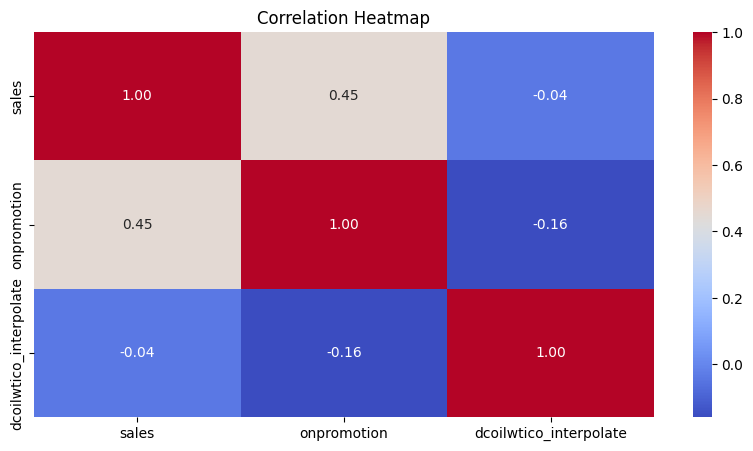

In [24]:
plt.figure(figsize=(10, 5))
correlation_matrix = df_store[['sales', 'onpromotion', 'dcoilwtico_interpolate' ]].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Check Missing Date

Check Missing Date family Grocery

In [25]:
# Filter hanya data dengan family "GROCERY I"
df_grocery = df_store[df_store["family"] == "GROCERY I"]
df_grocery

,id,date,store_nbr,family,sales,onpromotion,dcoilwtico,dcoilwtico_interpolate
12,1464,2013-01-01,5,GROCERY I,0.0,0,NaN,93.140000
45,3246,2013-01-02,5,GROCERY I,4558.0,0,93.14,93.140000
78,5028,2013-01-03,5,GROCERY I,3260.0,0,92.97,92.970000
111,6810,2013-01-04,5,GROCERY I,3085.0,0,93.12,93.120000
144,8592,2013-01-05,5,GROCERY I,3398.0,0,NaN,93.126220
...,...,...,...,...,...,...,...,...
55419,2993442,2017-08-11,5,GROCERY I,2864.0,35,48.81,48.810000
55452,2995224,2017-08-12,5,GROCERY I,2476.0,31,NaN,48.715146
55485,2997006,2017-08-13,5,GROCERY I,3141.0,31,NaN,47.832655
55518,2998788,2017-08-14,5,GROCERY I,2717.0,32,47.59,47.590000


In [26]:
df_grocery = df_grocery[['date','store_nbr','family','sales','onpromotion','dcoilwtico']]

In [27]:
# Buat rentang tanggal lengkap berdasarkan min & max
full_date_range = pd.date_range(start=df_grocery['date'].min(), end=df_grocery['date'].max(), freq='D')

In [28]:
# Cari tanggal yang hilang
missing_dates = full_date_range.difference(df_grocery['date'])
missing_dates

DatetimeIndex(['2013-12-25', '2014-12-25', '2015-12-25', '2016-12-25'], dtype='datetime64[ns]', freq=None)

In [29]:
# Filter hanya bulan Desember
df_december = df_grocery[df_grocery['date'].dt.month == 12]
df_december.head(60)

,date,store_nbr,family,sales,onpromotion,dcoilwtico
11034,2013-12-01,5,GROCERY I,4969.0,0,NaN
11067,2013-12-02,5,GROCERY I,3034.0,0,93.61
11100,2013-12-03,5,GROCERY I,2650.0,0,95.83
11133,2013-12-04,5,GROCERY I,2962.0,0,96.97
11166,2013-12-05,5,GROCERY I,2971.0,0,97.14
11199,2013-12-06,5,GROCERY I,2946.0,0,97.48
11232,2013-12-07,5,GROCERY I,3467.0,0,NaN
11265,2013-12-08,5,GROCERY I,4078.0,0,NaN
11298,2013-12-09,5,GROCERY I,4625.0,0,97.10
11331,2013-12-10,5,GROCERY I,2405.0,0,98.32


In [30]:
missing_dates[missing_dates.dayofyear == 1]  # Cek Tahun Baru

DatetimeIndex([], dtype='datetime64[ns]', freq=None)

In [31]:
missing_dates[missing_dates.dayofyear == 364]

DatetimeIndex([], dtype='datetime64[ns]', freq=None)

Memasukkan missing date yang tidak ada ('2013-12-25', '2014-12-25', '2015-12-25', '2016-12-25') ke dalam dataframe

In [32]:
# Set index ke 'date' dan reindex dengan full_date_range
df_grocery = df_grocery.set_index('date').reindex(full_date_range).reset_index()

# Pastikan kolom tetap bernama 'date'
df_grocery.rename(columns={'index': 'date'}, inplace=True)

# Isi sales dan onpromotion dengan 0, tetapi dcoilwtico tetap NaN
df_grocery[['sales', 'onpromotion']] = df_grocery[['sales', 'onpromotion']].fillna(0)

df_grocery

,date,store_nbr,family,sales,onpromotion,dcoilwtico
0,2013-01-01,5.0,GROCERY I,0.0,0.0,NaN
1,2013-01-02,5.0,GROCERY I,4558.0,0.0,93.14
2,2013-01-03,5.0,GROCERY I,3260.0,0.0,92.97
3,2013-01-04,5.0,GROCERY I,3085.0,0.0,93.12
4,2013-01-05,5.0,GROCERY I,3398.0,0.0,NaN
...,...,...,...,...,...,...
1683,2017-08-11,5.0,GROCERY I,2864.0,35.0,48.81
1684,2017-08-12,5.0,GROCERY I,2476.0,31.0,NaN
1685,2017-08-13,5.0,GROCERY I,3141.0,31.0,NaN
1686,2017-08-14,5.0,GROCERY I,2717.0,32.0,47.59


In [33]:
# Filter hanya bulan Desember
df_december = df_grocery[df_grocery['date'].dt.month == 12]
df_december.head(60)

,date,store_nbr,family,sales,onpromotion,dcoilwtico
334,2013-12-01,5.0,GROCERY I,4969.0,0.0,NaN
335,2013-12-02,5.0,GROCERY I,3034.0,0.0,93.61
336,2013-12-03,5.0,GROCERY I,2650.0,0.0,95.83
337,2013-12-04,5.0,GROCERY I,2962.0,0.0,96.97
338,2013-12-05,5.0,GROCERY I,2971.0,0.0,97.14
339,2013-12-06,5.0,GROCERY I,2946.0,0.0,97.48
340,2013-12-07,5.0,GROCERY I,3467.0,0.0,NaN
341,2013-12-08,5.0,GROCERY I,4078.0,0.0,NaN
342,2013-12-09,5.0,GROCERY I,4625.0,0.0,97.10
343,2013-12-10,5.0,GROCERY I,2405.0,0.0,98.32


Ubah data yang baru dimasukkan dengan ketentuan store_nbr = 5 dan family = Grocery I

In [34]:
import numpy as np

# Isi missing store_nbr dengan 5 dan family dengan "GROCERY I"
df_grocery['store_nbr'] = df_grocery['store_nbr'].fillna(5).astype(int)
df_grocery['family'] = df_grocery['family'].fillna("GROCERY I")
df_grocery

,date,store_nbr,family,sales,onpromotion,dcoilwtico
0,2013-01-01,5,GROCERY I,0.0,0.0,NaN
1,2013-01-02,5,GROCERY I,4558.0,0.0,93.14
2,2013-01-03,5,GROCERY I,3260.0,0.0,92.97
3,2013-01-04,5,GROCERY I,3085.0,0.0,93.12
4,2013-01-05,5,GROCERY I,3398.0,0.0,NaN
...,...,...,...,...,...,...
1683,2017-08-11,5,GROCERY I,2864.0,35.0,48.81
1684,2017-08-12,5,GROCERY I,2476.0,31.0,NaN
1685,2017-08-13,5,GROCERY I,3141.0,31.0,NaN
1686,2017-08-14,5,GROCERY I,2717.0,32.0,47.59


Cek apakah sudah sesuai dengan yang diubah di atas, store_nbr = 5 dan family = Grocery I

In [35]:
# Filter hanya bulan Desember
df_december = df_grocery[df_grocery['date'].dt.month == 12]
df_december.head(60)

,date,store_nbr,family,sales,onpromotion,dcoilwtico
334,2013-12-01,5,GROCERY I,4969.0,0.0,NaN
335,2013-12-02,5,GROCERY I,3034.0,0.0,93.61
336,2013-12-03,5,GROCERY I,2650.0,0.0,95.83
337,2013-12-04,5,GROCERY I,2962.0,0.0,96.97
338,2013-12-05,5,GROCERY I,2971.0,0.0,97.14
339,2013-12-06,5,GROCERY I,2946.0,0.0,97.48
340,2013-12-07,5,GROCERY I,3467.0,0.0,NaN
341,2013-12-08,5,GROCERY I,4078.0,0.0,NaN
342,2013-12-09,5,GROCERY I,4625.0,0.0,97.10
343,2013-12-10,5,GROCERY I,2405.0,0.0,98.32


Check lagi apakah masih ada missing date

In [36]:
# Buat rentang tanggal lengkap berdasarkan min & max
full_date_range = pd.date_range(start=df_grocery['date'].min(), end=df_grocery['date'].max(), freq='D')

# Cari tanggal yang hilang
missing_dates = full_date_range.difference(df_grocery['date'])
missing_dates

DatetimeIndex([], dtype='datetime64[ns]', freq='D')

Cek Plot Sales vs dcoilwtico, OnPromotion vs dcoilwtico

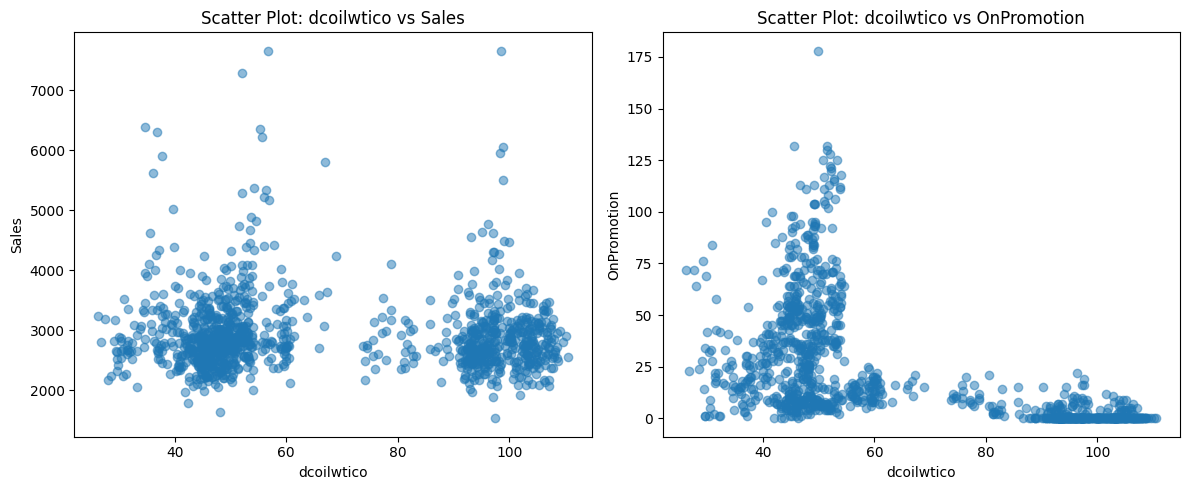

In [37]:
import matplotlib.pyplot as plt

# Scatter plot dcoilwtico vs sales
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(df_grocery["dcoilwtico"], df_grocery["sales"], alpha=0.5)
plt.xlabel("dcoilwtico")
plt.ylabel("Sales")
plt.title("Scatter Plot: dcoilwtico vs Sales")

# Scatter plot dcoilwtico vs onpromotion
plt.subplot(1, 2, 2)
plt.scatter(df_grocery["dcoilwtico"], df_grocery["onpromotion"], alpha=0.5)
plt.xlabel("dcoilwtico")
plt.ylabel("OnPromotion")
plt.title("Scatter Plot: dcoilwtico vs OnPromotion")

plt.tight_layout()
plt.show()

1. Distribusi tidak membentuk garis lurus, sehingga model linear mungkin gagal menangkap pola.
2. Terdapat lonjakan (non-monotonik) pada onpromotion, yang lebih baik ditangani oleh polynomial.
3. Data sales memiliki variasi tinggi, yang mungkin tidak bisa dijelaskan hanya dengan model linier.

# Checking Missing Value untuk Grocery I, karena ada penambahan pada date

Missing value diselesaikan dengan cara yang sama seperti di atas menggunakan Polinomial

In [38]:
df_grocery['dcoilwtico_interpolate'] = (
    df_grocery['dcoilwtico']
    .interpolate(method='polynomial', order=2)
    .fillna(method='bfill')  # Mengisi NaN awal dengan nilai pertama yang valid
)

<ipython-input-38-a50e278a32d0>:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method='bfill')  # Mengisi NaN awal dengan nilai pertama yang valid


In [39]:
# Cek apakah ada NaN setelah interpolasi
print(df_grocery.isna().sum())

date                        0
store_nbr                   0
family                      0
sales                       0
onpromotion                 0
dcoilwtico                525
dcoilwtico_interpolate      0
dtype: int64


In [40]:
df_grocery

,date,store_nbr,family,sales,onpromotion,dcoilwtico,dcoilwtico_interpolate
0,2013-01-01,5,GROCERY I,0.0,0.0,NaN,93.140000
1,2013-01-02,5,GROCERY I,4558.0,0.0,93.14,93.140000
2,2013-01-03,5,GROCERY I,3260.0,0.0,92.97,92.970000
3,2013-01-04,5,GROCERY I,3085.0,0.0,93.12,93.120000
4,2013-01-05,5,GROCERY I,3398.0,0.0,NaN,93.205338
...,...,...,...,...,...,...,...
1683,2017-08-11,5,GROCERY I,2864.0,35.0,48.81,48.810000
1684,2017-08-12,5,GROCERY I,2476.0,31.0,NaN,48.717426
1685,2017-08-13,5,GROCERY I,3141.0,31.0,NaN,48.020802
1686,2017-08-14,5,GROCERY I,2717.0,32.0,47.59,47.590000


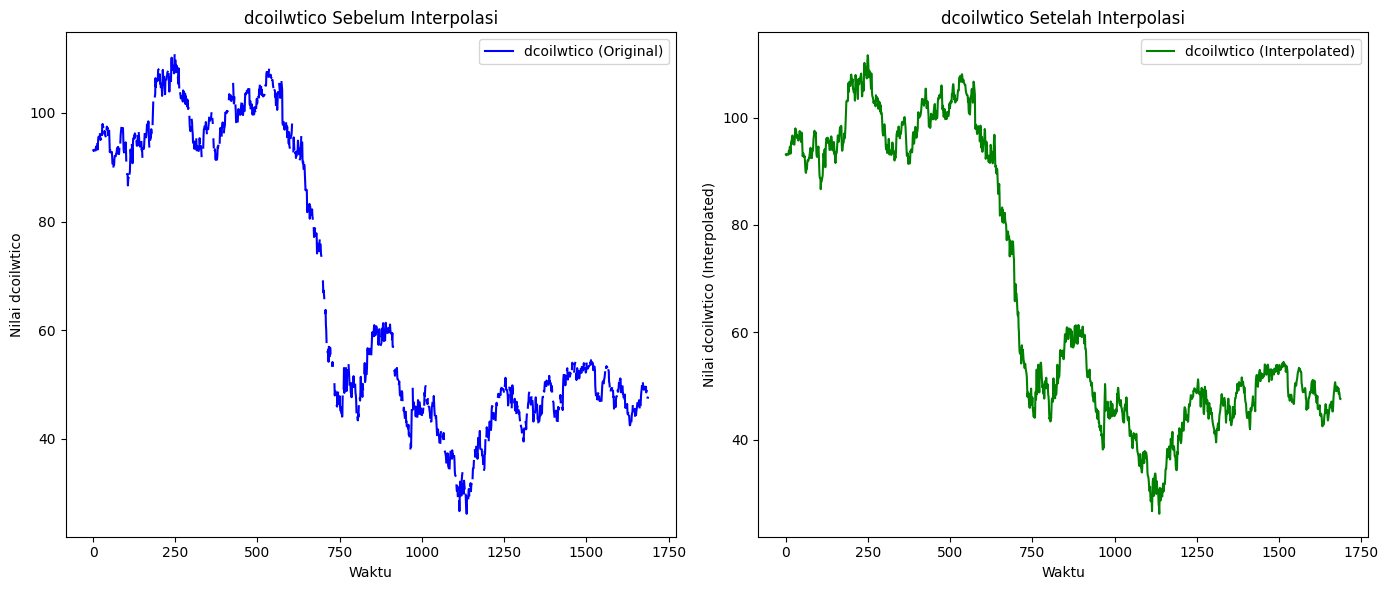

In [41]:
import matplotlib.pyplot as plt

# Membuat plot perbandingan sebelum dan sesudah interpolasi
plt.figure(figsize=(14, 6))

# Plot dcoilwtico sebelum interpolasi
plt.subplot(1, 2, 1)
plt.plot(df_grocery['dcoilwtico'], label='dcoilwtico (Original)', color='blue')
plt.title('dcoilwtico Sebelum Interpolasi')
plt.xlabel('Waktu')
plt.ylabel('Nilai dcoilwtico')
plt.legend()

# Plot dcoilwtico setelah interpolasi
plt.subplot(1, 2, 2)
plt.plot(df_grocery['dcoilwtico_interpolate'], label='dcoilwtico (Interpolated)', color='green')
plt.title('dcoilwtico Setelah Interpolasi')
plt.xlabel('Waktu')
plt.ylabel('Nilai dcoilwtico (Interpolated)')
plt.legend()

plt.tight_layout()
plt.show()

# Check Outlier Data

# **EDA**

# Visualization untuk Sales dan Onpromotion pada Grocery I

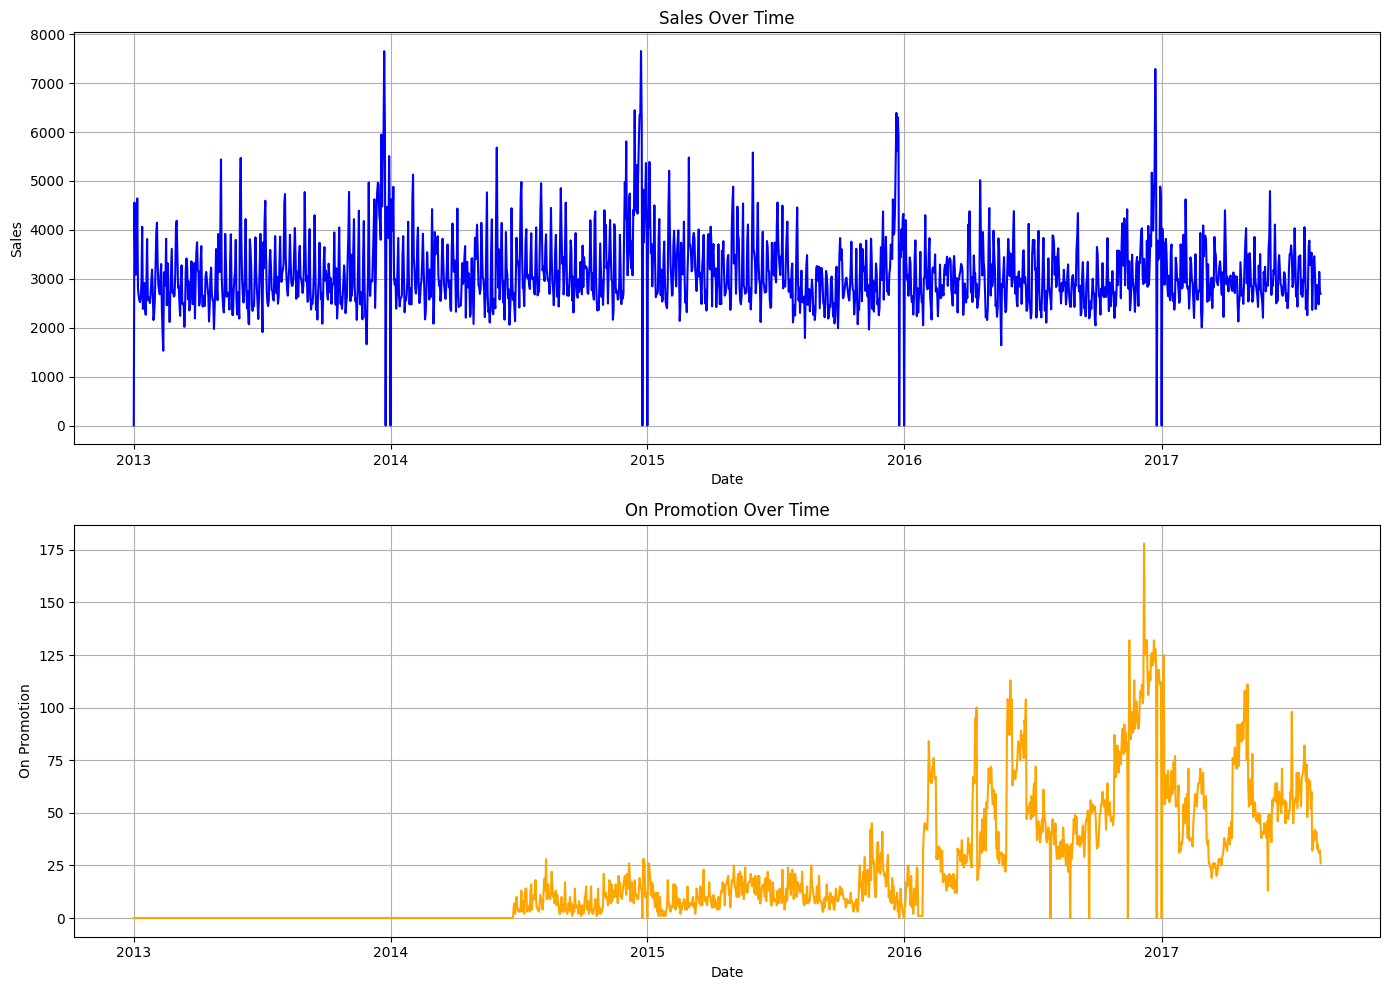

In [42]:
import matplotlib.pyplot as plt

plt.style.use('default')

plt.figure(figsize=(14, 10), facecolor='white')

# Plot Sales
plt.subplot(2, 1, 1)
plt.plot(df_grocery['date'], df_grocery['sales'], color='blue')
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)

# Plot On Promotion
plt.subplot(2, 1, 2)
plt.plot(df_grocery['date'], df_grocery['onpromotion'], color='orange')
plt.title("On Promotion Over Time")
plt.xlabel("Date")
plt.ylabel("On Promotion")
plt.grid(True)

plt.tight_layout()
plt.show()

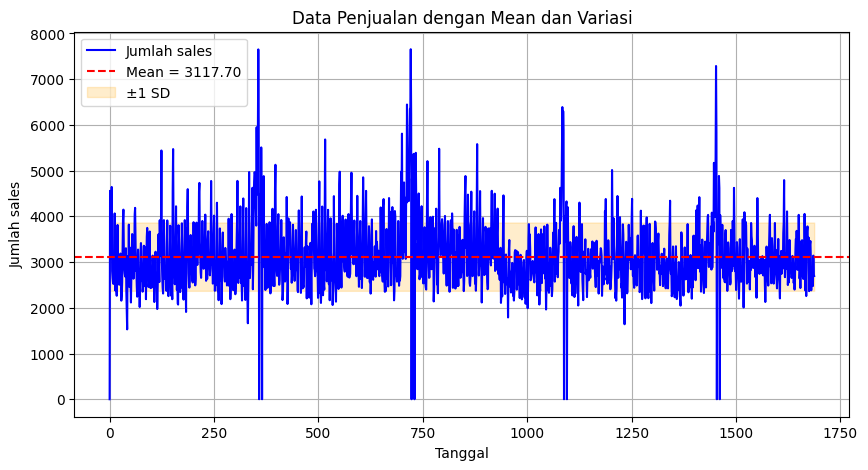

In [43]:
# Hitung Mean dan Standar Deviasi
mean_value =  df_grocery['sales'].mean()
std_value =  df_grocery['sales'].std()

# Plot Data Penjualan
plt.figure(figsize=(10, 5))
plt.plot( df_grocery['sales'], label='Jumlah sales', color='blue')

# Tambahkan Garis Mean
plt.axhline(y=mean_value, color='red', linestyle='--', label=f'Mean = {mean_value:.2f}')

# Tambahkan Area Variasi (±1 Standar Deviasi)
plt.fill_between(
    df_grocery.index,
    mean_value - std_value,
    mean_value + std_value,
    color='orange',
    alpha=0.2,
    label='±1 SD'
)

# Tambahkan Detail dan Keterangan
plt.title('Data Penjualan dengan Mean dan Variasi')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah sales')
plt.grid(True)
plt.legend()
plt.show()

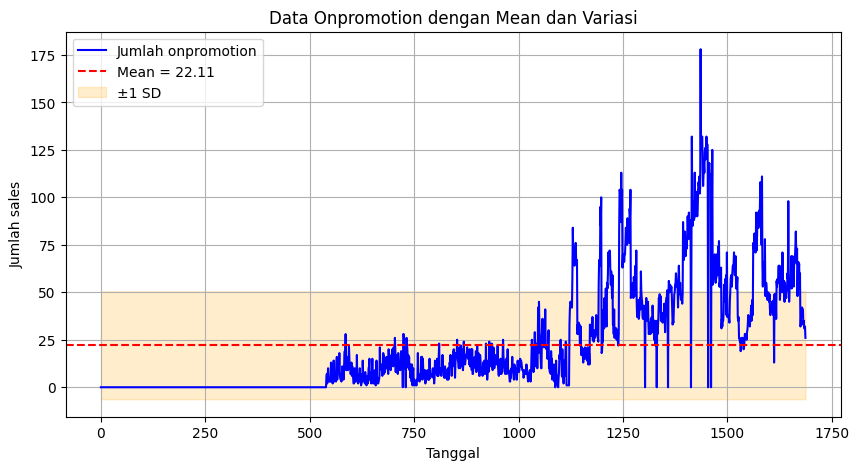

In [44]:
# Hitung Mean dan Standar Deviasi
mean_value =  df_grocery['onpromotion'].mean()
std_value =  df_grocery['onpromotion'].std()

# Plot Data Penjualan
plt.figure(figsize=(10, 5))
plt.plot( df_grocery['onpromotion'], label='Jumlah onpromotion', color='blue')

# Tambahkan Garis Mean
plt.axhline(y=mean_value, color='red', linestyle='--', label=f'Mean = {mean_value:.2f}')

# Tambahkan Area Variasi (±1 Standar Deviasi)
plt.fill_between(
    df_grocery.index,
    mean_value - std_value,
    mean_value + std_value,
    color='orange',
    alpha=0.2,
    label='±1 SD'
)

# Tambahkan Detail dan Keterangan
plt.title('Data Onpromotion dengan Mean dan Variasi')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah sales')
plt.grid(True)
plt.legend()
plt.show()

In [45]:
from statsmodels.tsa.stattools import adfuller

# Fungsi untuk ADF Test dan menampilkan hasil lengkap
def adf_test(series, series_name="Time Series"):
    result = adfuller(series.dropna())
    print(f"ADF Test for {series_name}:")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print(f"Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.4f}")
    if result[1] < 0.05:
        print("=> Data is stationary (reject H0)")
    else:
        print("=> Data is non-stationary (fail to reject H0)")

# Contoh ADF test untuk sales dan onpromotion
adf_test(df_grocery['sales'], "Sales")
adf_test(df_grocery['onpromotion'], "OnPromotion")

ADF Test for Sales:
ADF Statistic: -7.1433
p-value: 0.0000
Critical Values:
   1%: -3.4343
   5%: -2.8633
   10%: -2.5677
=> Data is stationary (reject H0)
ADF Test for OnPromotion:
ADF Statistic: -2.6803
p-value: 0.0775
Critical Values:
   1%: -3.4343
   5%: -2.8633
   10%: -2.5677
=> Data is non-stationary (fail to reject H0)


Hasil uji ADF Test
*  Sales: Stasioner
*  OnPromotion: Non Stasioner



On Promotion dilakukan Stasioneritas Data - Differensing

In [46]:
df_grocery['onpromotion_diff'] = df_grocery['onpromotion'].diff()
df_grocery

,date,store_nbr,family,sales,onpromotion,dcoilwtico,dcoilwtico_interpolate,onpromotion_diff
0,2013-01-01,5,GROCERY I,0.0,0.0,NaN,93.140000,NaN
1,2013-01-02,5,GROCERY I,4558.0,0.0,93.14,93.140000,0.0
2,2013-01-03,5,GROCERY I,3260.0,0.0,92.97,92.970000,0.0
3,2013-01-04,5,GROCERY I,3085.0,0.0,93.12,93.120000,0.0
4,2013-01-05,5,GROCERY I,3398.0,0.0,NaN,93.205338,0.0
...,...,...,...,...,...,...,...,...
1683,2017-08-11,5,GROCERY I,2864.0,35.0,48.81,48.810000,2.0
1684,2017-08-12,5,GROCERY I,2476.0,31.0,NaN,48.717426,-4.0
1685,2017-08-13,5,GROCERY I,3141.0,31.0,NaN,48.020802,0.0
1686,2017-08-14,5,GROCERY I,2717.0,32.0,47.59,47.590000,1.0


In [47]:
# Uji ADF untuk mengecek stasioneritas
result = adfuller(df_grocery['onpromotion_diff'].dropna())

# Print hasil ADF Test
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

# Jika p-value > 0.05, berarti tidak stasioner
if result[1] > 0.05:
    print("Data tidak stasioner, perlu differencing.")
else:
    print("Data sudah stasioner.")

ADF Statistic: -9.669167854280806
p-value: 1.2907189853224762e-16
Data sudah stasioner.


In [48]:
# Buat rentang tanggal lengkap berdasarkan min & max
full_date_range = pd.date_range(start=df_grocery['date'].min(), end=df_grocery['date'].max(), freq='D')

# Cari tanggal yang hilang
missing_dates = full_date_range.difference(df_grocery['date'])
missing_dates

DatetimeIndex([], dtype='datetime64[ns]', freq='D')

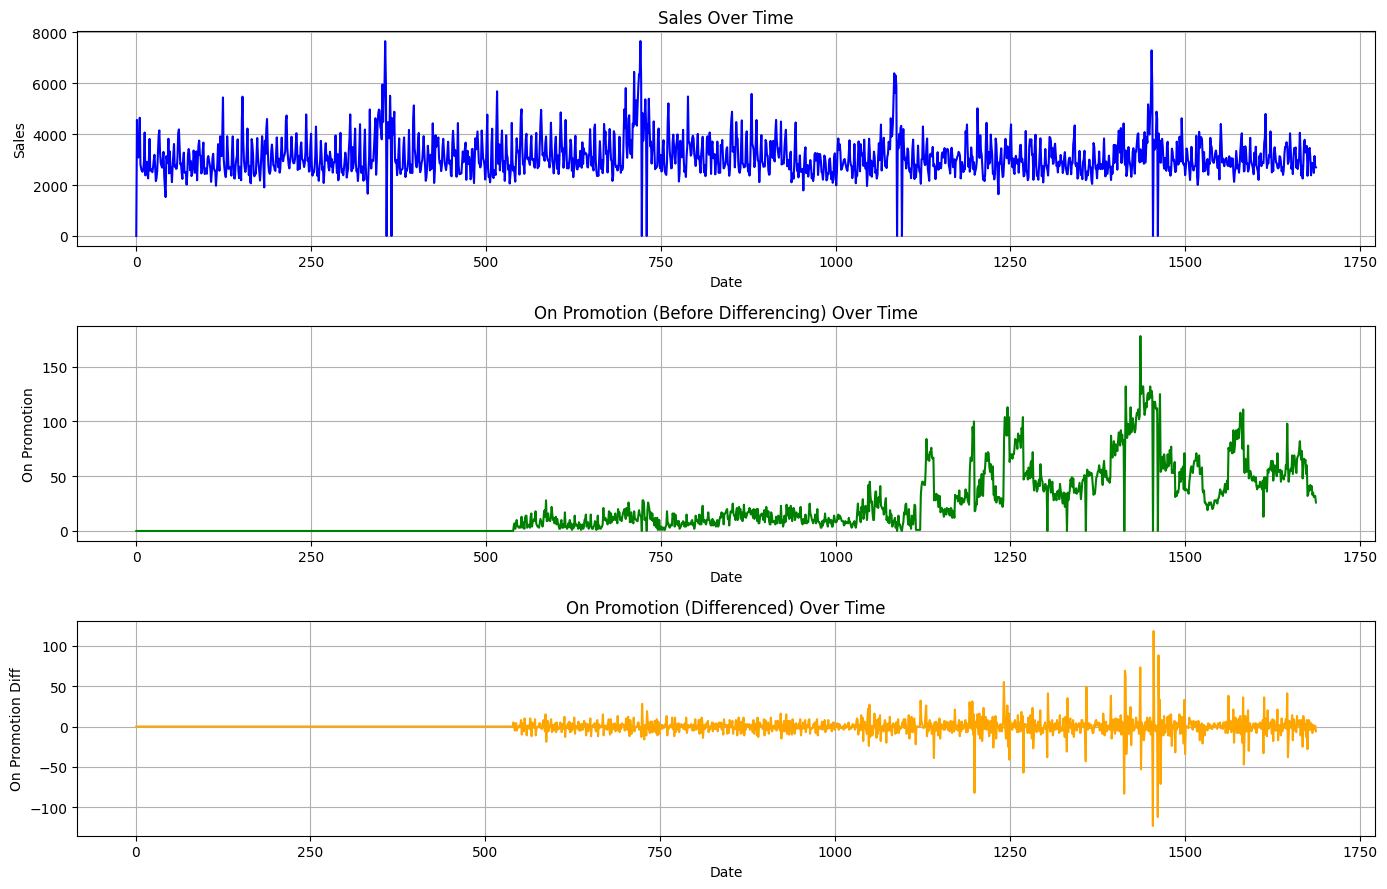

In [49]:
plt.figure(figsize=(14, 9))

# Plot Sales
plt.subplot(3, 1, 1)
plt.plot(df_grocery.index, df_grocery['sales'], color='blue')
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)

# Plot On Promotion (Before Differencing)
plt.subplot(3, 1, 2)
plt.plot(df_grocery.index, df_grocery['onpromotion'], color='green')
plt.title("On Promotion (Before Differencing) Over Time")
plt.xlabel("Date")
plt.ylabel("On Promotion")
plt.grid(True)

# Plot On Promotion (Differenced)
plt.subplot(3, 1, 3)
plt.plot(df_grocery.index, df_grocery['onpromotion_diff'], color='orange')
plt.title("On Promotion (Differenced) Over Time")
plt.xlabel("Date")
plt.ylabel("On Promotion Diff")
plt.grid(True)

plt.tight_layout()
plt.show()

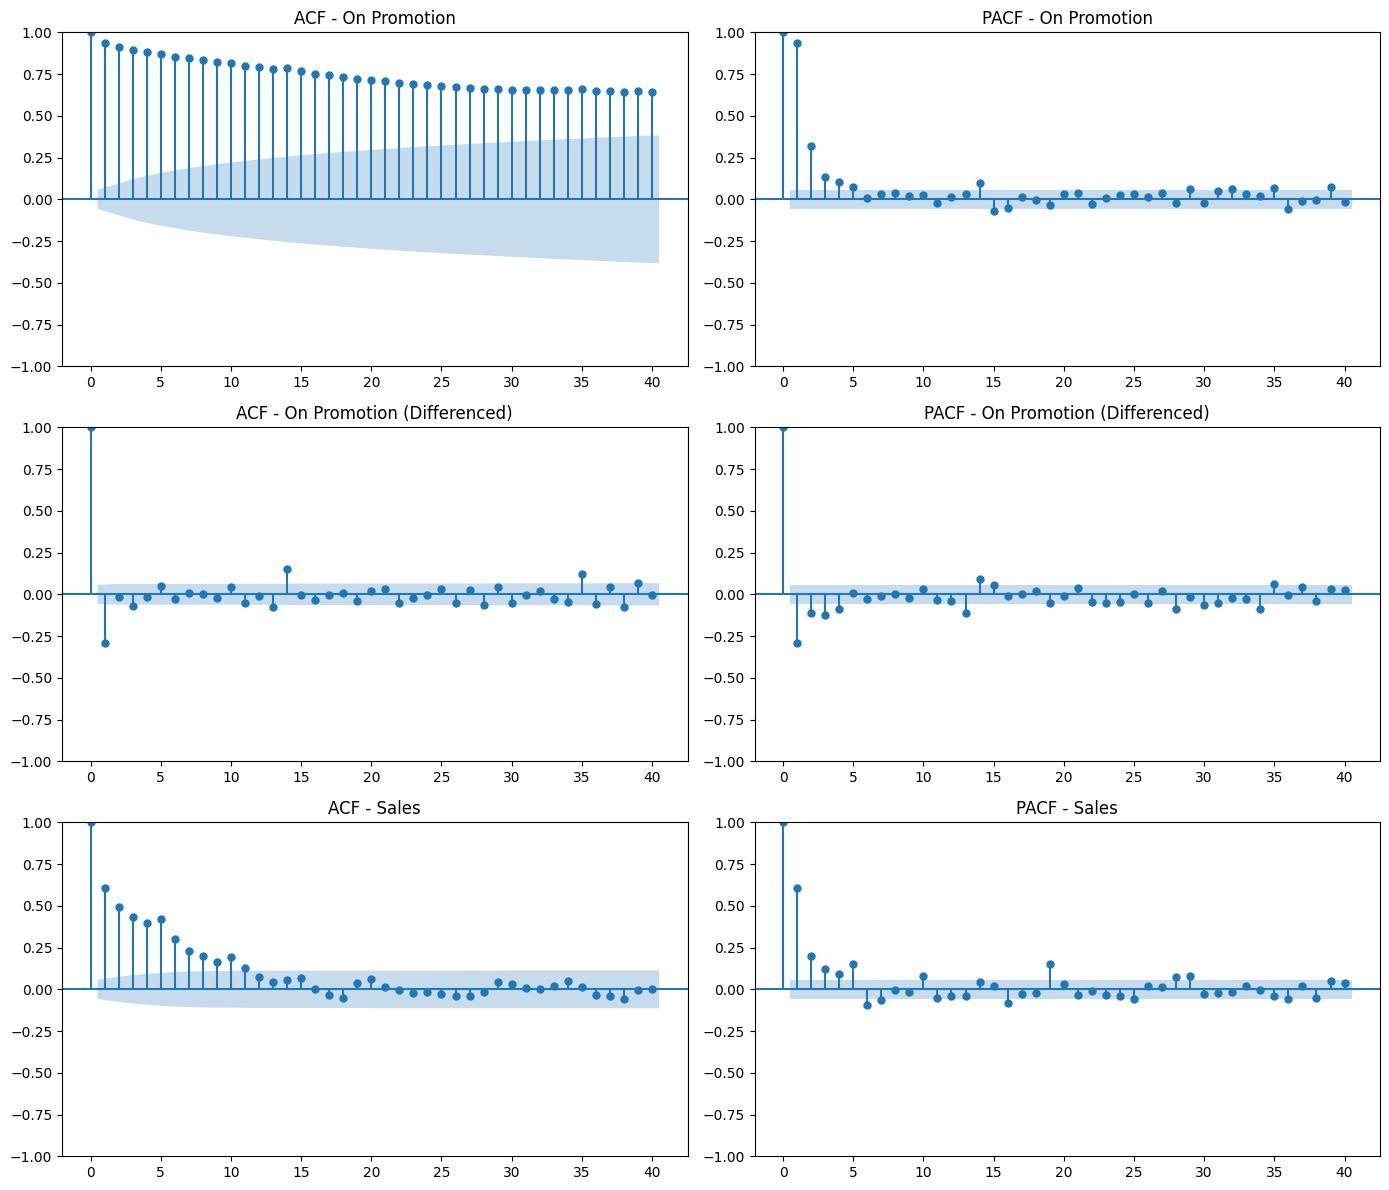

In [50]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Pastikan tanggal dalam format datetime
df_grocery['date'] = pd.to_datetime(df_grocery['date'])
df_grocery.set_index('date', inplace=True)

# Lakukan differencing untuk onpromotion
df_grocery['onpromotion_diff'] = df_grocery['onpromotion'].diff()

# Drop NaN akibat differencing
df_grocery.dropna(inplace=True)


fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# ACF & PACF On Promotion (Sebelum Differencing)
plot_acf(df_grocery['onpromotion'], lags=40, ax=axes[0, 0])
axes[0, 0].set_title("ACF - On Promotion")

plot_pacf(df_grocery['onpromotion'], lags=40, ax=axes[0, 1])
axes[0, 1].set_title("PACF - On Promotion")

# ACF & PACF On Promotion (Setelah Differencing)
plot_acf(df_grocery['onpromotion_diff'], lags=40, ax=axes[1, 0])
axes[1, 0].set_title("ACF - On Promotion (Differenced)")

plot_pacf(df_grocery['onpromotion_diff'], lags=40, ax=axes[1, 1])
axes[1, 1].set_title("PACF - On Promotion (Differenced)")

# ACF & PACF Sales
plot_acf(df_grocery['sales'], lags=40, ax=axes[2, 0])
axes[2, 0].set_title("ACF - Sales")

plot_pacf(df_grocery['sales'], lags=40, ax=axes[2, 1])
axes[2, 1].set_title("PACF - Sales")

plt.tight_layout()
plt.show()

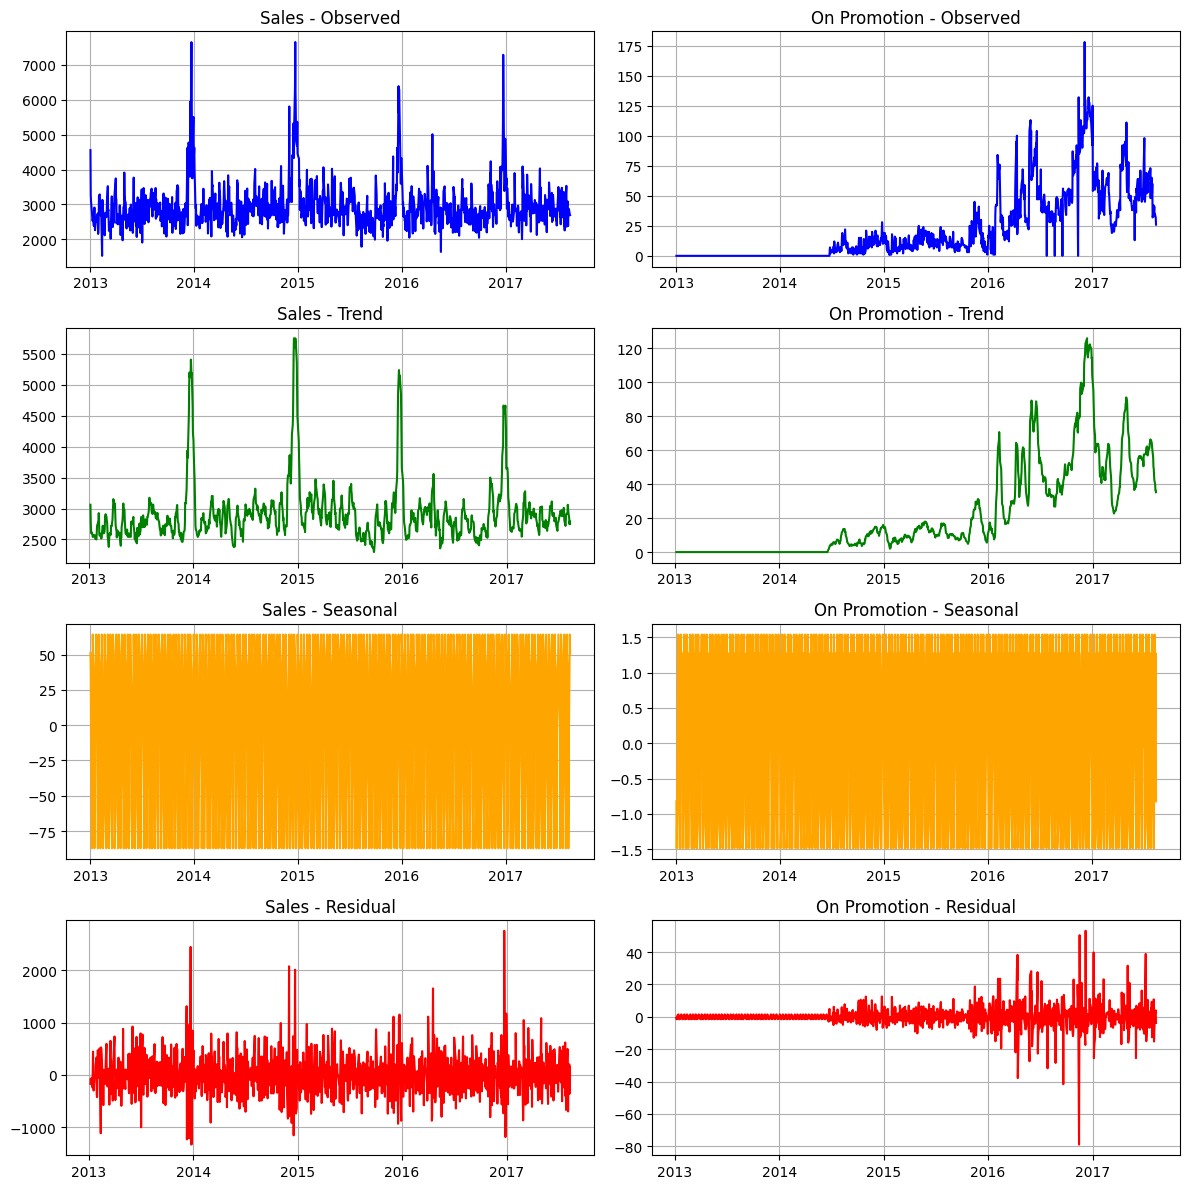

In [51]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose Sales dan On Promotion
decomp_sales = seasonal_decompose(df_grocery['sales'], model='additive', period=7)
decomp_onpromo = seasonal_decompose(df_grocery['onpromotion'], model='additive', period=7)

fig, axes = plt.subplots(4, 2, figsize=(12, 12))

# Warna untuk membedakan setiap plot
colors = ['blue', 'green', 'orange', 'red']

# Sales Decomposition
axes[0, 0].plot(decomp_sales.observed, color=colors[0])
axes[0, 0].set_title("Sales - Observed")
axes[1, 0].plot(decomp_sales.trend, color=colors[1])
axes[1, 0].set_title("Sales - Trend")
axes[2, 0].plot(decomp_sales.seasonal, color=colors[2])
axes[2, 0].set_title("Sales - Seasonal")
axes[3, 0].plot(decomp_sales.resid, color=colors[3])
axes[3, 0].set_title("Sales - Residual")

# On Promotion Decomposition
axes[0, 1].plot(decomp_onpromo.observed, color=colors[0])
axes[0, 1].set_title("On Promotion - Observed")
axes[1, 1].plot(decomp_onpromo.trend, color=colors[1])
axes[1, 1].set_title("On Promotion - Trend")
axes[2, 1].plot(decomp_onpromo.seasonal, color=colors[2])
axes[2, 1].set_title("On Promotion - Seasonal")
axes[3, 1].plot(decomp_onpromo.resid, color=colors[3])
axes[3, 1].set_title("On Promotion - Residual")

# Tambahkan grid untuk memperjelas pola
for ax in axes.flat:
    ax.grid(True)

plt.tight_layout()
plt.show()

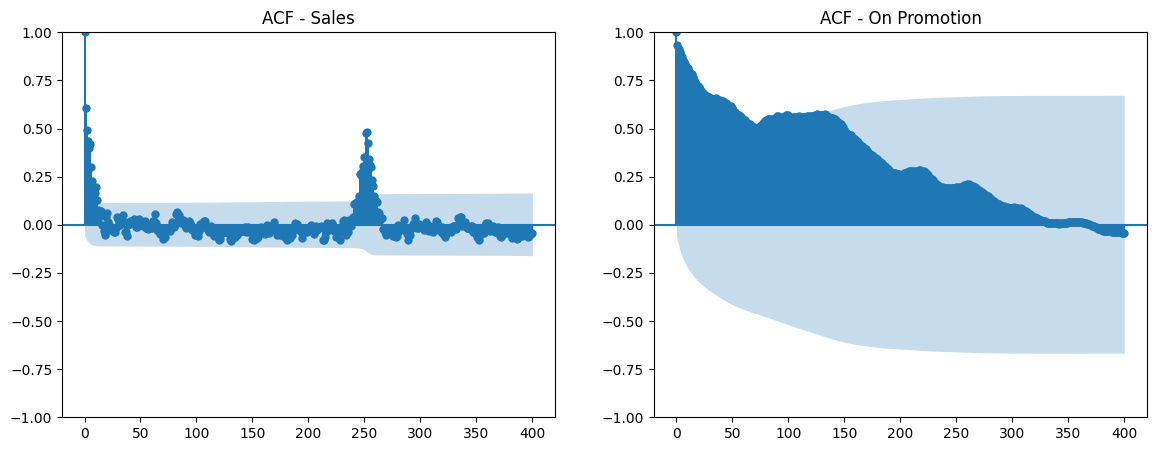

In [52]:
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ACF Sales
plot_acf(df_grocery['sales'], lags=400, ax=axes[0])
axes[0].set_title("ACF - Sales")

# ACF On Promotion
plot_acf(df_grocery['onpromotion'], lags=400, ax=axes[1])
axes[1].set_title("ACF - On Promotion")

plt.show()

In [53]:
df_grocery

,store_nbr,family,sales,onpromotion,dcoilwtico,dcoilwtico_interpolate,onpromotion_diff
date,,,,,,,
2013-01-02,5,GROCERY I,4558.0,0.0,93.14,93.14,0.0
2013-01-03,5,GROCERY I,3260.0,0.0,92.97,92.97,0.0
2013-01-04,5,GROCERY I,3085.0,0.0,93.12,93.12,0.0
2013-01-07,5,GROCERY I,2801.0,0.0,93.20,93.20,0.0
2013-01-08,5,GROCERY I,2651.0,0.0,93.21,93.21,0.0
...,...,...,...,...,...,...,...
2017-08-09,5,GROCERY I,2872.0,41.0,49.59,49.59,3.0
2017-08-10,5,GROCERY I,2687.0,33.0,48.54,48.54,-8.0
2017-08-11,5,GROCERY I,2864.0,35.0,48.81,48.81,2.0


In [54]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import acf

# Hitung ACF untuk sales
acf_values = acf(df_grocery['sales'], nlags=1100, fft=False)  # Gunakan fft=False untuk akurasi lebih baik

# Buat DataFrame baru untuk hasil ACF tanpa mengubah df_grocery
acf_df = pd.DataFrame({'Lag': np.arange(len(acf_values)), 'ACF_Sales': acf_values})

# Tentukan jumlah observasi
n = len(df_grocery['sales'])

# Hitung batas konfidensi 95%
conf_interval = 1.96 / np.sqrt(n)

# Tambahkan kolom untuk batas bawah dan atas
acf_df['Lower_Bound'] = -conf_interval
acf_df['Upper_Bound'] = conf_interval

# Filter hanya untuk lag tahunan (365, 730, 1095)
acf_yearly = acf_df[acf_df['Lag'].isin([365, 730, 1095])]

# Evaluasi apakah nilai ACF signifikan (di luar batas konfidensi)
acf_yearly['Significant'] = (acf_yearly['ACF_Sales'] > acf_yearly['Upper_Bound']) | (acf_yearly['ACF_Sales'] < acf_yearly['Lower_Bound'])

# Tampilkan hasil
acf_yearly

<ipython-input-54-2a68a75e42ed>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  acf_yearly['Significant'] = (acf_yearly['ACF_Sales'] > acf_yearly['Upper_Bound']) | (acf_yearly['ACF_Sales'] < acf_yearly['Lower_Bound'])


,Lag,ACF_Sales,Lower_Bound,Upper_Bound,Significant
365,365,-0.005091,-0.057473,0.057473,False
730,730,-0.012035,-0.057473,0.057473,False
1095,1095,0.004081,-0.057473,0.057473,False


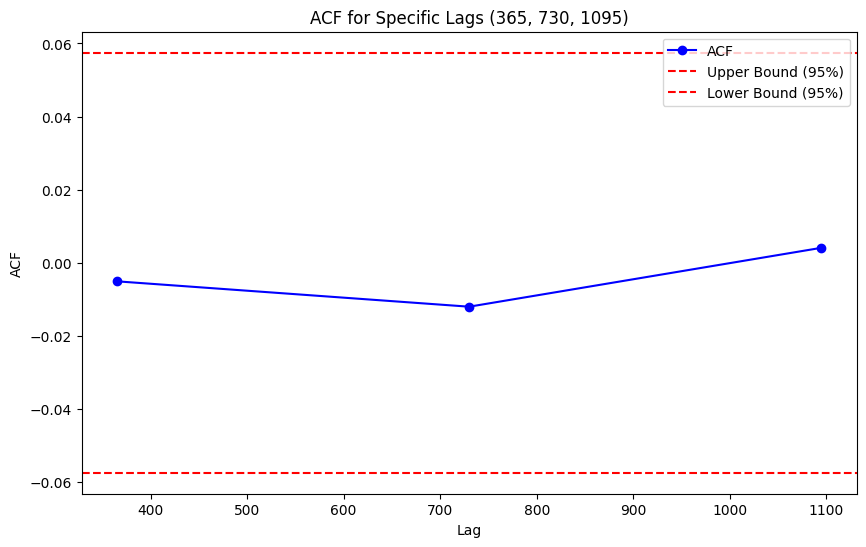

In [55]:
# Filter ACF hanya untuk lag 365, 730, 1095
acf_yearly = acf_df[acf_df['Lag'].isin([365, 730, 1095])]

# Plot ACF untuk lag tersebut
plt.figure(figsize=(10, 6))
plt.plot(acf_yearly['Lag'], acf_yearly['ACF_Sales'], marker='o', color='b', label='ACF')

# Tambahkan garis batas konfidensi
plt.axhline(y=1.96/np.sqrt(n), color='r', linestyle='--', label='Upper Bound (95%)')
plt.axhline(y=-1.96/np.sqrt(n), color='r', linestyle='--', label='Lower Bound (95%)')

# Menambahkan label dan judul
plt.title('ACF for Specific Lags (365, 730, 1095)')
plt.xlabel('Lag')
plt.ylabel('ACF')
plt.legend()

# Tampilkan chart
plt.show()

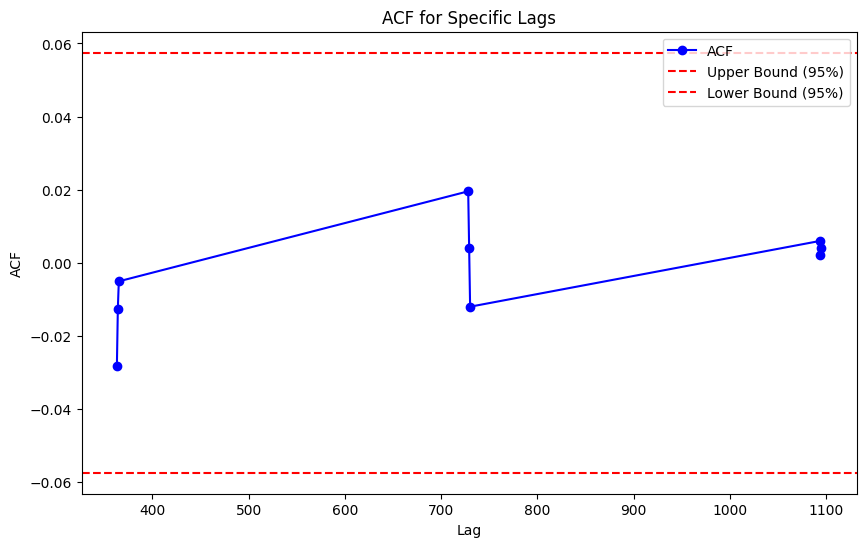

In [56]:
# Filter ACF hanya untuk lag tertentu
acf_somelags = acf_df[acf_df['Lag'].isin([363, 364, 365, 728, 729, 730, 1093, 1094, 1095])]

# Plot ACF untuk lag tersebut
plt.figure(figsize=(10, 6))
plt.plot(acf_somelags['Lag'], acf_somelags['ACF_Sales'], marker='o', color='b', label='ACF')

# Tambahkan garis batas konfidensi
plt.axhline(y=1.96/np.sqrt(n), color='r', linestyle='--', label='Upper Bound (95%)')
plt.axhline(y=-1.96/np.sqrt(n), color='r', linestyle='--', label='Lower Bound (95%)')

# Menambahkan label dan judul
plt.title('ACF for Specific Lags')
plt.xlabel('Lag')
plt.ylabel('ACF')
plt.legend()

# Tampilkan chart
plt.show()

In [57]:
df_grocery

,store_nbr,family,sales,onpromotion,dcoilwtico,dcoilwtico_interpolate,onpromotion_diff
date,,,,,,,
2013-01-02,5,GROCERY I,4558.0,0.0,93.14,93.14,0.0
2013-01-03,5,GROCERY I,3260.0,0.0,92.97,92.97,0.0
2013-01-04,5,GROCERY I,3085.0,0.0,93.12,93.12,0.0
2013-01-07,5,GROCERY I,2801.0,0.0,93.20,93.20,0.0
2013-01-08,5,GROCERY I,2651.0,0.0,93.21,93.21,0.0
...,...,...,...,...,...,...,...
2017-08-09,5,GROCERY I,2872.0,41.0,49.59,49.59,3.0
2017-08-10,5,GROCERY I,2687.0,33.0,48.54,48.54,-8.0
2017-08-11,5,GROCERY I,2864.0,35.0,48.81,48.81,2.0


In [58]:
from scipy.stats import boxcox

df_grocery_new = df_store[['date','store_nbr','family','sales','onpromotion','dcoilwtico']]

In [59]:
# Filter hanya data dengan family "GROCERY I"
df_grocery_new = df_store[df_store["family"] == "GROCERY I"]

# Set index ke 'date' dan reindex dengan full_date_range
df_grocery_new = df_grocery_new.set_index('date').reindex(full_date_range).reset_index()

# Pastikan kolom tetap bernama 'date'
df_grocery_new.rename(columns={'index': 'date'}, inplace=True)

# Isi sales dan onpromotion dengan 0, tetapi dcoilwtico tetap NaN
df_grocery_new[['sales', 'onpromotion']] = df_grocery_new[['sales', 'onpromotion']].fillna(0)

# Isi missing store_nbr dengan 5 dan family dengan "GROCERY I"
df_grocery_new['store_nbr'] = df_grocery_new['store_nbr'].fillna(5).astype(int)
df_grocery_new['family'] = df_grocery_new['family'].fillna("GROCERY I")

In [60]:
df_grocery_new

,date,id,store_nbr,family,sales,onpromotion,dcoilwtico,dcoilwtico_interpolate
0,2013-01-01,1464.0,5,GROCERY I,0.0,0.0,NaN,93.140000
1,2013-01-02,3246.0,5,GROCERY I,4558.0,0.0,93.14,93.140000
2,2013-01-03,5028.0,5,GROCERY I,3260.0,0.0,92.97,92.970000
3,2013-01-04,6810.0,5,GROCERY I,3085.0,0.0,93.12,93.120000
4,2013-01-05,8592.0,5,GROCERY I,3398.0,0.0,NaN,93.126220
...,...,...,...,...,...,...,...,...
1683,2017-08-11,2993442.0,5,GROCERY I,2864.0,35.0,48.81,48.810000
1684,2017-08-12,2995224.0,5,GROCERY I,2476.0,31.0,NaN,48.715146
1685,2017-08-13,2997006.0,5,GROCERY I,3141.0,31.0,NaN,47.832655
1686,2017-08-14,2998788.0,5,GROCERY I,2717.0,32.0,47.59,47.590000


In [61]:
df_grocery_new['onpromotion_boxcox'], lambda_bc = boxcox(df_grocery_new['onpromotion'] + 1)
df_grocery_new

,date,id,store_nbr,family,sales,onpromotion,dcoilwtico,dcoilwtico_interpolate,onpromotion_boxcox
0,2013-01-01,1464.0,5,GROCERY I,0.0,0.0,NaN,93.140000,0.000000
1,2013-01-02,3246.0,5,GROCERY I,4558.0,0.0,93.14,93.140000,0.000000
2,2013-01-03,5028.0,5,GROCERY I,3260.0,0.0,92.97,92.970000,0.000000
3,2013-01-04,6810.0,5,GROCERY I,3085.0,0.0,93.12,93.120000,0.000000
4,2013-01-05,8592.0,5,GROCERY I,3398.0,0.0,NaN,93.126220,0.000000
...,...,...,...,...,...,...,...,...,...
1683,2017-08-11,2993442.0,5,GROCERY I,2864.0,35.0,48.81,48.810000,3.968569
1684,2017-08-12,2995224.0,5,GROCERY I,2476.0,31.0,NaN,48.715146,3.825072
1685,2017-08-13,2997006.0,5,GROCERY I,3141.0,31.0,NaN,47.832655,3.825072
1686,2017-08-14,2998788.0,5,GROCERY I,2717.0,32.0,47.59,47.590000,3.862470


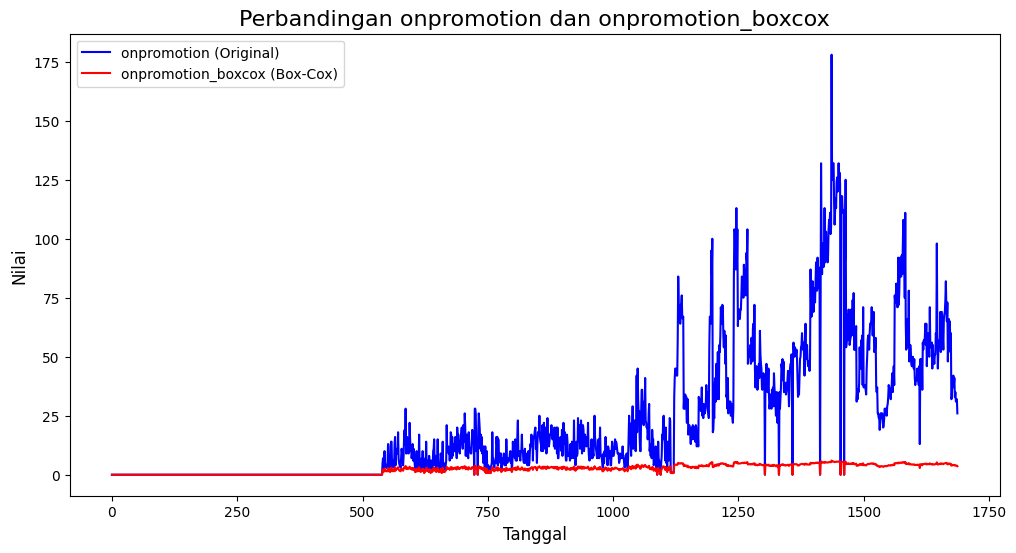

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot 'onpromotion' (data asli)
plt.plot(df_grocery_new.index, df_grocery_new['onpromotion'], label='onpromotion (Original)', color='blue')

# Plot 'onpromotion_boxcox' (setelah Box-Cox)
plt.plot(df_grocery_new.index, df_grocery_new['onpromotion_boxcox'], label='onpromotion_boxcox (Box-Cox)', color='red')

# Menambahkan label dan judul
plt.title('Perbandingan onpromotion dan onpromotion_boxcox', fontsize=16)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Nilai', fontsize=12)

# Menambahkan legenda
plt.legend()

# Menampilkan plot
plt.show()

In [63]:
# Menghitung jumlah missing (NaN) per kolom
missing_per_column = df_grocery_new.isna().sum()
missing_per_column

,0
date,0
id,4
store_nbr,0
family,0
sales,0
onpromotion,0
dcoilwtico,525
dcoilwtico_interpolate,4
onpromotion_boxcox,0


In [64]:
# Buat rentang tanggal lengkap berdasarkan min & max
full_date_range = pd.date_range(start=df_grocery_new['date'].min(), end=df_grocery_new['date'].max(), freq='D')

# Cari tanggal yang hilang
missing_dates = full_date_range.difference(df_grocery_new['date'])
missing_dates

DatetimeIndex([], dtype='datetime64[ns]', freq='D')

In [65]:
df_grocery_new

,date,id,store_nbr,family,sales,onpromotion,dcoilwtico,dcoilwtico_interpolate,onpromotion_boxcox
0,2013-01-01,1464.0,5,GROCERY I,0.0,0.0,NaN,93.140000,0.000000
1,2013-01-02,3246.0,5,GROCERY I,4558.0,0.0,93.14,93.140000,0.000000
2,2013-01-03,5028.0,5,GROCERY I,3260.0,0.0,92.97,92.970000,0.000000
3,2013-01-04,6810.0,5,GROCERY I,3085.0,0.0,93.12,93.120000,0.000000
4,2013-01-05,8592.0,5,GROCERY I,3398.0,0.0,NaN,93.126220,0.000000
...,...,...,...,...,...,...,...,...,...
1683,2017-08-11,2993442.0,5,GROCERY I,2864.0,35.0,48.81,48.810000,3.968569
1684,2017-08-12,2995224.0,5,GROCERY I,2476.0,31.0,NaN,48.715146,3.825072
1685,2017-08-13,2997006.0,5,GROCERY I,3141.0,31.0,NaN,47.832655,3.825072
1686,2017-08-14,2998788.0,5,GROCERY I,2717.0,32.0,47.59,47.590000,3.862470


In [66]:
df_grocery_new['dcoilwtico_interpolate'] = (
    df_grocery_new['dcoilwtico']
    .interpolate(method='polynomial', order=2)
    .fillna(method='bfill')  # Mengisi NaN awal dengan nilai pertama yang valid
)

<ipython-input-66-0c56973c9553>:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method='bfill')  # Mengisi NaN awal dengan nilai pertama yang valid


In [67]:
df_grocery_new

,date,id,store_nbr,family,sales,onpromotion,dcoilwtico,dcoilwtico_interpolate,onpromotion_boxcox
0,2013-01-01,1464.0,5,GROCERY I,0.0,0.0,NaN,93.140000,0.000000
1,2013-01-02,3246.0,5,GROCERY I,4558.0,0.0,93.14,93.140000,0.000000
2,2013-01-03,5028.0,5,GROCERY I,3260.0,0.0,92.97,92.970000,0.000000
3,2013-01-04,6810.0,5,GROCERY I,3085.0,0.0,93.12,93.120000,0.000000
4,2013-01-05,8592.0,5,GROCERY I,3398.0,0.0,NaN,93.205338,0.000000
...,...,...,...,...,...,...,...,...,...
1683,2017-08-11,2993442.0,5,GROCERY I,2864.0,35.0,48.81,48.810000,3.968569
1684,2017-08-12,2995224.0,5,GROCERY I,2476.0,31.0,NaN,48.717426,3.825072
1685,2017-08-13,2997006.0,5,GROCERY I,3141.0,31.0,NaN,48.020802,3.825072
1686,2017-08-14,2998788.0,5,GROCERY I,2717.0,32.0,47.59,47.590000,3.862470


# **Model using VARMAX**

In [68]:
from statsmodels.tsa.statespace.varmax import VARMAX
from sklearn.metrics import mean_absolute_error

# Pastikan kolom tanggal dalam format datetime
df_grocery_new['date'] = pd.to_datetime(df_grocery_new['date'])

# Set kolom tanggal sebagai indeks
df_grocery_new.set_index('date', inplace=True)

# Pisahkan variabel endogen dan eksogen
endog = df_grocery_new[['sales', 'onpromotion_boxcox']]
exog = df_grocery_new[['dcoilwtico_interpolate']]

# Pisahkan data menjadi train dan test
train_size = int(len(df_grocery) * 0.8)
train_endog, test_endog = endog.iloc[:train_size], endog.iloc[train_size:]
train_exog, test_exog = exog.iloc[:train_size], exog.iloc[train_size:]

In [69]:
train_endog

,sales,onpromotion_boxcox
date,,
2013-01-01,0.0,0.000000
2013-01-02,4558.0,0.000000
2013-01-03,3260.0,0.000000
2013-01-04,3085.0,0.000000
2013-01-05,3398.0,0.000000
...,...,...
2015-07-15,2865.0,1.684228
2015-07-16,2840.0,2.205411
2015-07-17,3482.0,2.924272


In [70]:
test_endog

,sales,onpromotion_boxcox
date,,
2015-07-20,3246.0,3.527375
2015-07-21,2736.0,2.999520
2015-07-22,2986.0,2.924272
2015-07-23,2835.0,3.374826
2015-07-24,2613.0,2.666188
...,...,...
2017-08-11,2864.0,3.968569
2017-08-12,2476.0,3.825072
2017-08-13,3141.0,3.825072


In [71]:
train_exog

,dcoilwtico_interpolate
date,
2013-01-01,93.140000
2013-01-02,93.140000
2013-01-03,92.970000
2013-01-04,93.120000
2013-01-05,93.205338
...,...
2015-07-15,51.400000
2015-07-16,50.900000
2015-07-17,50.880000


In [72]:
# import itertools
# from statsmodels.tsa.statespace.varmax import VARMAX
# from sklearn.metrics import mean_absolute_error
# from scipy.special import inv_boxcox  # Perbaiki impor di sini
# from scipy.stats import boxcox

# Grid search untuk parameter p dan q
# p_values = range(1, 5)  # Order autoregressive
# q_values = range(0, 4)  # Order moving average
# best_score = float("inf")
# best_cfg = None

# Coba semua kombinasi (p, q)
# for p, q in itertools.product(p_values, q_values):
#    try:
#         print(f"Evaluating VARMAX({p},{q})...")

        # Train model VARMAX
#         model = VARMAX(train_endog, exog=train_exog, order=(p, q), trend='c')
#         model_fit = model.fit(disp=False)

        # Forecast untuk data test
#         preds = model_fit.forecast(steps=len(test_endog), exog=test_exog)

        # Kembalikan prediksi 'onpromotion' ke skala data awal
#         preds['onpromotion'] = inv_boxcox(preds['onpromotion_boxcox'], lambda_bc) - 1  # Mengurangi 1 kembali

        # Hitung MAE antara prediksi dan data aktual
#         mae_sales = mean_absolute_error(test_endog['sales'], preds['sales'])
#         mae_promo = mean_absolute_error(test_endog['onpromotion_boxcox'], preds['onpromotion_boxcox'])
#         mae_total = mae_sales + mae_promo

#         print(f"VARMAX({p},{q}) - MAE: {mae_total:.4f}")

        # Simpan model dengan MAE terbaik
#         if mae_total < best_score:
#             best_score = mae_total
#             best_cfg = (p, q)

#     except Exception as e:
#         print(f"VARMAX({p},{q}) gagal dilatih: {e}")

# print(f"\nBest VARMAX order: {best_cfg} dengan MAE: {best_score:.4f}")

akurasi menggunakan MAE

In [73]:
import itertools
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.varmax import VARMAX
from sklearn.metrics import mean_absolute_error
from scipy.special import inv_boxcox  # Perbaiki impor di sini
from scipy.stats import boxcox

# Grid search untuk parameter p dan q
p_values = range(1, 5)  # Order autoregressive
q_values = range(0, 4)  # Order moving average
best_score = float("inf")
best_cfg = None
best_model = None

# Hitung rata-rata aktual untuk normalisasi
mean_sales = test_endog['sales'].mean()
mean_promo = test_endog['onpromotion_boxcox'].mean()

# Coba semua kombinasi (p, q)
for p, q in itertools.product(p_values, q_values):
    try:
        print(f"Evaluating VARMAX({p},{q})...")

        # Train model VARMAX
        model = VARMAX(train_endog, exog=train_exog, order=(p, q), trend='c')
        model_fit = model.fit(disp=False)

        # Forecast untuk data test
        preds = model_fit.forecast(steps=len(test_endog), exog=test_exog)

        # Kembalikan prediksi 'onpromotion' ke skala data awal
        preds['onpromotion'] = inv_boxcox(preds['onpromotion_boxcox'], lambda_bc) - 1  # Mengurangi 1 kembali
        test_endog['onpromotion'] = inv_boxcox(test_endog['onpromotion_boxcox'], lambda_bc) - 1  # Konversi actual juga

        # Hitung MAE antara prediksi dan data aktual
        mae_sales = mean_absolute_error(test_endog['sales'], preds['sales'])
        mae_promo = mean_absolute_error(test_endog['onpromotion'], preds['onpromotion'])

        # Normalisasi MAE
        mae_sales_norm = mae_sales / mean_sales
        mae_promo_norm = mae_promo / mean_promo
        mae_normalized = mae_sales_norm + mae_promo_norm  # Gabungkan kesalahan yang telah dinormalisasi

        print(f"VARMAX({p},{q}) - Normalized MAE: {mae_normalized:.4f}")

        # Simpan model dengan MAE terbaik
        if mae_normalized < best_score:
            best_score = mae_normalized
            best_cfg = (p, q)
            best_model = model_fit

    except Exception as e:
        print(f"VARMAX({p},{q}) gagal dilatih: {e}")

print(f"\nBest VARMAX order: {best_cfg} dengan Normalized MAE: {best_score:.4f}")

Evaluating VARMAX(1,0)...


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
<ipython-input-73-ca175b918cbf>:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_endog['onpromotion'] = inv_boxcox(test_endog['onpromotion_boxcox'], lambda_bc) - 1  # Konversi actual juga
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning

VARMAX(1,0) - Normalized MAE: 8.5951
Evaluating VARMAX(1,1)...


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
<ipython-input-73-ca175b918cbf>:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.py

VARMAX(1,1) - Normalized MAE: 8.3613
Evaluating VARMAX(1,2)...


...

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
<ipython-input-73-ca175b918cbf>:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_endog['onpromotion'] = inv_boxcox(test_endog['onpromotion_boxcox'], lambda_bc) - 1  # Konversi actual juga
/usr/local/lib/python3.1

VARMAX(4,2) - Normalized MAE: 8.6938
Evaluating VARMAX(4,3)...


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


VARMAX(4,3) - Normalized MAE: 8.9417

Best VARMAX order: (1, 3) dengan Normalized MAE: 8.2138


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
<ipython-input-73-ca175b918cbf>:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_endog['onpromotion'] = inv_boxcox(test_endog['onpromotion_boxcox'], lambda_bc) - 1  # Konversi actual juga


In [74]:
# Gunakan model terbaik untuk prediksi
test_preds = best_model.forecast(steps=len(test_endog), exog=test_exog)

# Kembalikan prediksi 'onpromotion' ke skala data awal untuk visualisasi
test_preds['onpromotion'] = inv_boxcox(test_preds['onpromotion_boxcox'], lambda_bc) - 1

test_preds

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'


,sales,onpromotion_boxcox,onpromotion
2015-07-20,3693.759835,2.552192,9.863945
2015-07-21,3398.862773,2.517339,9.537390
2015-07-22,3383.146144,2.567513,10.010486
2015-07-23,3400.696310,2.633507,10.663336
2015-07-24,3410.355547,2.690780,11.259363
...,...,...,...
2017-08-11,3434.663213,3.006033,15.089449
2017-08-12,3435.034110,3.008141,15.118501
2017-08-13,3436.717646,3.014892,15.211884
2017-08-14,3438.535841,3.023719,15.334741


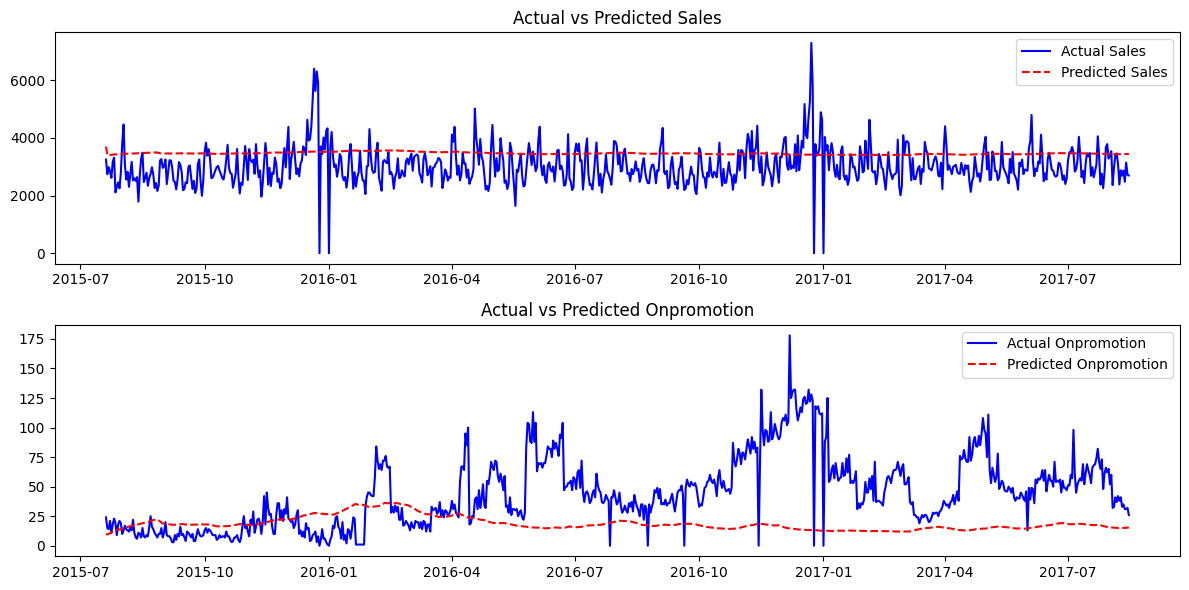

In [75]:
# Plot hasil prediksi vs actual
plt.figure(figsize=(12, 6))

# Plot Sales
plt.subplot(2, 1, 1)
plt.plot(test_endog.index, test_endog['sales'], label='Actual Sales', color='blue')
plt.plot(test_endog.index, test_preds['sales'], label='Predicted Sales', color='red', linestyle='dashed')
plt.title('Actual vs Predicted Sales')
plt.legend()

# Plot Onpromotion (sudah dalam skala asli)
plt.subplot(2, 1, 2)
plt.plot(test_endog.index, test_endog['onpromotion'], label='Actual Onpromotion', color='blue')
plt.plot(test_endog.index, test_preds['onpromotion'], label='Predicted Onpromotion', color='red', linestyle='dashed')
plt.title('Actual vs Predicted Onpromotion')
plt.legend()

plt.tight_layout()
plt.show()

akurasi menggunakan RMSE

In [76]:
from sklearn.metrics import mean_squared_error

# # Menghitung RMSE untuk Sales
rmse_sales = np.sqrt(mean_squared_error(test_endog['sales'], test_preds['sales']))

# # Menghitung RMSE untuk Onpromotion
rmse_onpromotion = np.sqrt(mean_squared_error(test_endog['onpromotion'], test_preds['onpromotion']))

# # Menampilkan RMSE
print(f'RMSE for Sales: {rmse_sales:.4f}')
print(f'RMSE for Onpromotion: {rmse_onpromotion:.4f}')

RMSE for Sales: 785.5736
RMSE for Onpromotion: 40.8586


In [77]:
# import itertools
# import matplotlib.pyplot as plt
# from statsmodels.tsa.statespace.varmax import VARMAX
# from sklearn.metrics import mean_squared_error
# from scipy.special import inv_boxcox  # Perbaiki impor di sini
# from scipy.stats import boxcox

# Grid search untuk parameter p dan q
# p_values = range(1, 5)  # Order autoregressive
# q_values = range(0, 4)  # Order moving average
# best_score = float("inf")
# best_cfg = None
# best_model = None

# Hitung rata-rata aktual untuk normalisasi
# mean_sales = test_endog['sales'].mean()
# mean_promo = test_endog['onpromotion_boxcox'].mean()

# Coba semua kombinasi (p, q)
# for p, q in itertools.product(p_values, q_values):
#     try:
#         print(f"Evaluating VARMAX({p},{q})...")

        # Train model VARMAX
        # model = VARMAX(train_endog, exog=train_exog, order=(p, q), trend='c')
        # model_fit = model.fit(disp=False)

        # Forecast untuk data test
        # preds = model_fit.forecast(steps=len(test_endog), exog=test_exog)

        # Gunakan model terbaik untuk prediksi
         # test_preds = best_model.forecast(steps=len(test_endog), exog=test_exog)

        # Kembalikan prediksi 'onpromotion' ke skala data awal
        #  preds['onpromotion'] = inv_boxcox(preds['onpromotion_boxcox'], lambda_bc) - 1  # Mengurangi 1 kembali
         # test_endog['onpromotion'] = inv_boxcox(test_endog['onpromotion_boxcox'], lambda_bc) - 1  # Konversi actual juga

        # Hitung MAE antara prediksi dan data aktual
        # mae_sales = mean_absolute_error(test_endog['sales'], preds['sales'])
        # mae_promo = mean_absolute_error(test_endog['onpromotion'], preds['onpromotion'])

        # Normalisasi MAE
        # mae_sales_norm = mae_sales / mean_sales
        # mae_promo_norm = mae_promo / mean_promo
        # mae_normalized = mae_sales_norm + mae_promo_norm  # Gabungkan kesalahan yang telah dinormalisasi

        # Hitung RMSE
         # rmse_sales = np.sqrt(mean_squared_error(test_endog['sales'], test_preds['sales']))
         # rmse_onpromotion = np.sqrt(mean_squared_error(test_endog['onpromotion'], test_preds['onpromotion']))

        # Menampilkan RMSE
         # print(f'RMSE for Sales: {rmse_sales:.4f}')
         # print(f'RMSE for Onpromotion: {rmse_onpromotion:.4f}')

        # Normalisasi RMSE (tidak perlu normalisasi)
        # rmse_sales = rmse_sales / mean_sales
        # rmse_promo = rmse_promo / mean_promo
        # rmse_normalized = rmse_sales + rmse_promo  # Gabungkan kesalahan yang telah dinormalisasi

        # print(f"VARMAX({p},{q}) - Normalized RMSE: {rmse_normalized:.4f} - RMSE Sales : {rmse_sales:.4f} - RMSE Promo : {rmse_promo:.4f} ")

        # Simpan model dengan MAE terbaik
        # if rmse_normalized < best_score:
        #     best_score = rmse_normalized
        #     best_cfg = (p, q)
        #     best_model = model_fit

    # except Exception as e:
    #    print(f"VARMAX({p},{q}) gagal dilatih: {e}")

# print(f"\nBest VARMAX order: {best_cfg} dengan Normalized RMSE: {best_score:.4f}  dan RMSE Sales : {rmse_sales:.4f} - RMSE Promo : {rmse_promo:.4f} "  )

In [78]:
# Gunakan model terbaik untuk prediksi
test_preds = best_model.forecast(steps=len(test_endog), exog=test_exog)

# Kembalikan prediksi 'onpromotion' ke skala data awal untuk visualisasi
test_preds['onpromotion'] = inv_boxcox(test_preds['onpromotion_boxcox'], lambda_bc) - 1

test_preds

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'


,sales,onpromotion_boxcox,onpromotion
2015-07-20,3693.759835,2.552192,9.863945
2015-07-21,3398.862773,2.517339,9.537390
2015-07-22,3383.146144,2.567513,10.010486
2015-07-23,3400.696310,2.633507,10.663336
2015-07-24,3410.355547,2.690780,11.259363
...,...,...,...
2017-08-11,3434.663213,3.006033,15.089449
2017-08-12,3435.034110,3.008141,15.118501
2017-08-13,3436.717646,3.014892,15.211884
2017-08-14,3438.535841,3.023719,15.334741


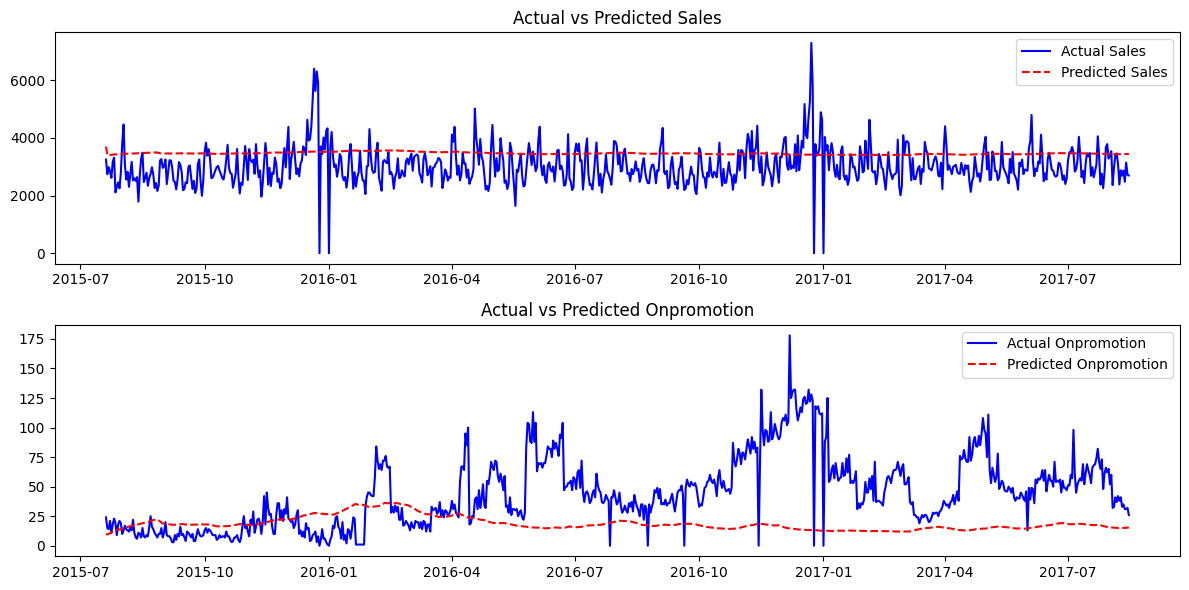

In [79]:
# Plot hasil prediksi vs actual
plt.figure(figsize=(12, 6))

# Plot Sales
plt.subplot(2, 1, 1)
plt.plot(test_endog.index, test_endog['sales'], label='Actual Sales', color='blue')
plt.plot(test_endog.index, test_preds['sales'], label='Predicted Sales', color='red', linestyle='dashed')
plt.title('Actual vs Predicted Sales')
plt.legend()

# Plot Onpromotion (sudah dalam skala asli)
plt.subplot(2, 1, 2)
plt.plot(test_endog.index, test_endog['onpromotion'], label='Actual Onpromotion', color='blue')
plt.plot(test_endog.index, test_preds['onpromotion'], label='Predicted Onpromotion', color='red', linestyle='dashed')
plt.title('Actual vs Predicted Onpromotion')
plt.legend()

plt.tight_layout()
plt.show()

# **LSTM**

# Modelling Using Single Layer LSTM

In [80]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import time
from sklearn.metrics import mean_squared_error

# Preprocessing
scaler_endog = MinMaxScaler()
scaler_exog = MinMaxScaler()

# Pisahkan variabel endogen dan eksogen
endog = df_grocery_new[['sales', 'onpromotion']]
exog = df_grocery_new[['dcoilwtico_interpolate']]

# Pisahkan data menjadi train dan test
train_size = int(len(df_grocery) * 0.8)
train_endog, test_endog = endog.iloc[:train_size], endog.iloc[train_size:]
train_exog, test_exog = exog.iloc[:train_size], exog.iloc[train_size:]

# Scaling the data (already done earlier)
endog_scaled = scaler_endog.fit_transform(endog)
exog_scaled = scaler_exog.fit_transform(exog)

In [81]:
# Check the shape of the endog_scaled (should have 2 columns)
print(f"endog_scaled shape: {endog_scaled.shape}")

endog_scaled shape: (1688, 2)


In [82]:
# Ensure endog_scaled has 2 columns (sales and onpromotion)
print(f"endog_scaled shape: {endog_scaled.shape}")  # (1688, 2)

# Combine exogenous (exog) and endogenous (endog) features into x
x = np.concatenate([exog_scaled, endog_scaled], axis=1)

# The target variable 'y' is the endog_scaled
y = endog_scaled  # 'sales' and 'onpromotion' as the target (2 columns)

endog_scaled shape: (1688, 2)


In [83]:
def load_data(X, seq_len, train_size=0.9):
    amount_of_features = X.shape[1]
    X_mat = X
    sequence_length = seq_len + 1
    data = []

    for index in range(len(X_mat) - sequence_length):
        data.append(X_mat[index: index + sequence_length])

    data = np.array(data)
    train_split = int(round(train_size * data.shape[0]))
    train_data = data[:train_split, :]

    x_train = train_data[:, :-1]
    y_train = train_data[:, -1, 1:]  # Select only the last 2 columns (sales and onpromotion)

    x_test = data[train_split:, :-1]
    y_test = data[train_split:, -1, 1:]  # Select only the last 2 columns (sales and onpromotion)

    # Check shapes before reshaping
    print(f"x_train shape (before reshape): {x_train.shape}")
    print(f"y_train shape (before reshape): {y_train.shape}")

    # Make sure y_train and y_test have 2 columns (for 'sales' and 'onpromotion')
    assert y_train.shape[1] == 2, "y_train should have 2 columns (sales and onpromotion)"
    assert y_test.shape[1] == 2, "y_test should have 2 columns (sales and onpromotion)"

    # Reshape x_train and x_test to 3D arrays for LSTM input
    x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], amount_of_features))
    x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], amount_of_features))

    return x_train, y_train, x_test, y_test

# Setting window size
window = 22
X_train, y_train, X_test, y_test = load_data(x, window)

# Print the shapes of data after loading and reshaping
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

x_train shape (before reshape): (1498, 22, 3)
y_train shape (before reshape): (1498, 2)
X_train shape: (1498, 22, 3), y_train shape: (1498, 2)
X_test shape: (167, 22, 3), y_test shape: (167, 2)


In [84]:
# LSTM Model
model = Sequential()
model.add(LSTM(units=50, input_shape=(window, X_train.shape[2])))
model.add(Dropout(0.2))

# Output layer with 2 units for 'sales' and 'onpromotion'
model.add(Dense(units=50, kernel_initializer='uniform', activation='tanh'))
model.add(Dense(units=2, kernel_initializer='uniform', activation='linear'))  # Two outputs

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Fit the model
start = time.time()
history = model.fit(X_train, y_train, epochs=100, batch_size=35, validation_split=0.05, verbose=1)
print('Compilation time: ', time.time() - start)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.0626 - val_loss: 0.0506
Epoch 2/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0142 - val_loss: 0.0218
Epoch 3/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0084 - val_loss: 0.0196
Epoch 4/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0072 - val_loss: 0.0184
Epoch 5/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0060 - val_loss: 0.0195
Epoch 6/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0068 - val_loss: 0.0192
Epoch 7/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0065 - val_loss: 0.0184
Epoch 8/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0063 - val_loss: 0.0180
Epoch 9/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0067 - val_loss: 0.0188
Epoch 10/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0061 - val_loss: 0.0192
Epoch 11/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0060 - val_loss: 0.0179
Epoch 12/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step

In [85]:
# Predictions
trainPredict = model.predict(X_train)
testPredict = model.predict(X_test)

# Inverse transform to get the actual values
trainPredict = scaler_endog.inverse_transform(trainPredict)
trainY = scaler_endog.inverse_transform(y_train)
testPredict = scaler_endog.inverse_transform(testPredict)
testY = scaler_endog.inverse_transform(y_test)

# Plotting
plot_predicted_sales = testPredict[:, 0].reshape(-1, 1)
plot_predicted_onpromotion = testPredict[:, 1].reshape(-1, 1)

plot_actual_sales = testY[:, 0].reshape(-1, 1)
plot_actual_onpromotion = testY[:, 1].reshape(-1, 1)

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


In [86]:
# Print shapes for verification
print(f"Plot actual sales shape: {plot_actual_sales.shape}")
print(f"Plot predicted sales shape: {plot_predicted_sales.shape}")

Plot actual sales shape: (167, 1)
Plot predicted sales shape: (167, 1)


In [87]:
# Calculate RMSE for both sales and onpromotion
trainScore_sales = mean_squared_error(trainY[:, 0], trainPredict[:, 0]) ** 0.5
testScore_sales = mean_squared_error(testY[:, 0], plot_predicted_sales[:, 0]) ** 0.5

trainScore_onpromotion = mean_squared_error(trainY[:, 1], trainPredict[:, 1]) ** 0.5
testScore_onpromotion = mean_squared_error(testY[:, 1], plot_predicted_onpromotion[:, 0]) ** 0.5

In [88]:
print(f'Train Score for sales: {trainScore_sales:.2f} RMSE')
print(f'Test Score for sales: {testScore_sales:.2f} RMSE')

print(f'Train Score for onpromotion: {trainScore_onpromotion:.2f} RMSE')
print(f'Test Score for onpromotion: {testScore_onpromotion:.2f} RMSE')

Train Score for sales: 637.72 RMSE
Test Score for sales: 413.37 RMSE
Train Score for onpromotion: 9.34 RMSE
Test Score for onpromotion: 10.59 RMSE


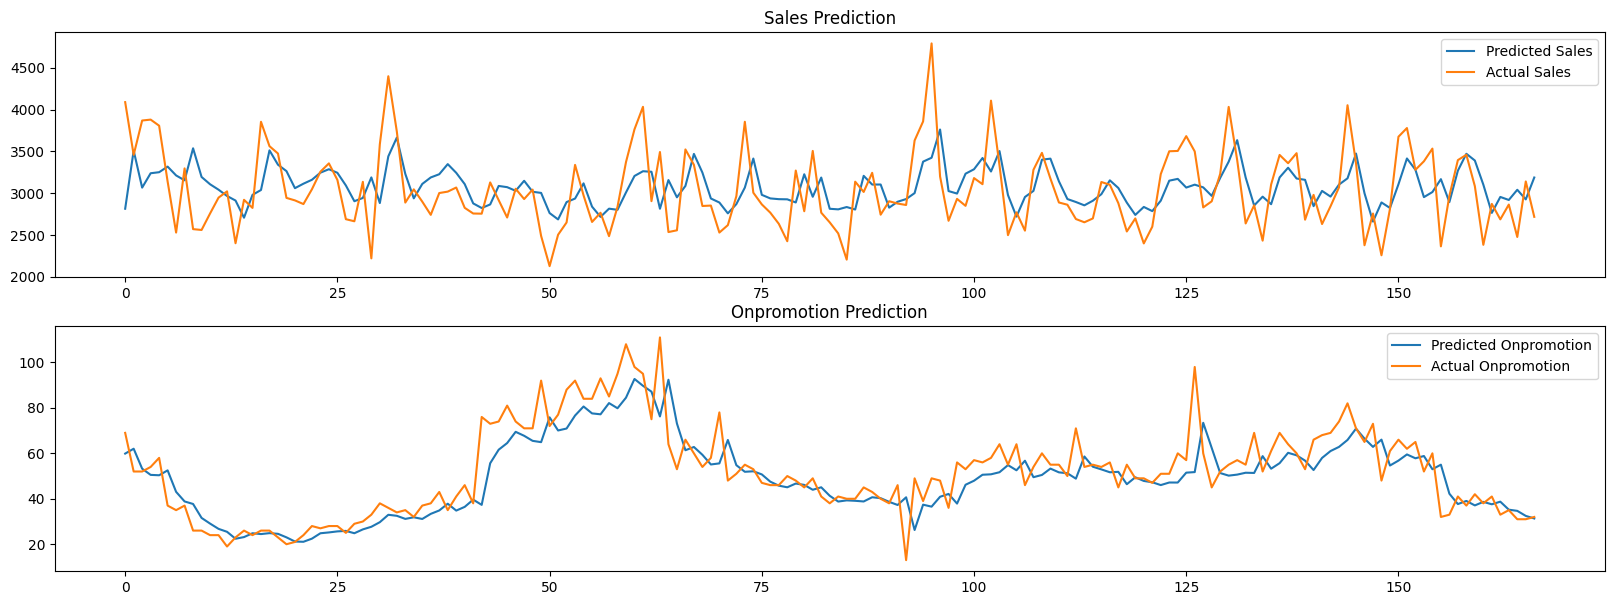

In [89]:
# Plot the results for both targets
plt.figure(figsize=(20, 7))

# Sales plot
plt.subplot(2, 1, 1)
plt.plot(pd.DataFrame(plot_predicted_sales), label='Predicted Sales')
plt.plot(pd.DataFrame(plot_actual_sales), label='Actual Sales')
plt.legend(loc='best')
plt.title('Sales Prediction')

# Onpromotion plot
plt.subplot(2, 1, 2)
plt.plot(pd.DataFrame(plot_predicted_onpromotion), label='Predicted Onpromotion')
plt.plot(pd.DataFrame(plot_actual_onpromotion), label='Actual Onpromotion')
plt.legend(loc='best')
plt.title('Onpromotion Prediction')

plt.show()

# Modelling Using Stacked LSTM Using Dropout

In [90]:
from tensorflow.keras.callbacks import EarlyStopping

# Stacked LSTM Model with Dropout
model2 = Sequential()

# First LSTM layer
model2.add(LSTM(units=50, return_sequences=True, input_shape=(window, X_train.shape[2])))
model2.add(Dropout(0.2))

# Second LSTM layer
model2.add(LSTM(units=50, return_sequences=True))
model2.add(Dropout(0.2))

# Third LSTM layer
model2.add(LSTM(units=50))
model2.add(Dropout(0.2))

# Dense layers
model2.add(Dense(units=50, kernel_initializer='uniform', activation='tanh'))
model2.add(Dense(units=2, kernel_initializer='uniform', activation='linear'))  # Two outputs (sales and onpromotion)

earlystop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=50)
callbacks_list = [earlystop]

# Compile the model
model2.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
start = time.time()
history = model2.fit(X_train, y_train, epochs=100, batch_size=35, validation_split=0.05, verbose=1)
print('Training time: ', time.time() - start)

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - loss: 0.0576 - val_loss: 0.0642
Epoch 2/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - loss: 0.0150 - val_loss: 0.0503
Epoch 3/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0091 - val_loss: 0.0297
Epoch 4/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0088 - val_loss: 0.0243
Epoch 5/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0090 - val_loss: 0.0212
Epoch 6/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0074 - val_loss: 0.0208
Epoch 7/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0080 - val_loss: 0.0217
Epoch 8/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0083 - val_loss: 0.0189
Epoch 9/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0074 - val_loss: 0.0191
Epoch 10/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - loss: 0.0076 - val_loss: 0.0235
Epoch 11/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0067 - val_loss: 0.0246
Epoch 12/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0

In [91]:
# Predictions
trainPredict = model2.predict(X_train)
testPredict = model2.predict(X_test)

# Inverse transform to get actual values
trainPredict = scaler_endog.inverse_transform(trainPredict)
trainY = scaler_endog.inverse_transform(y_train)
testPredict = scaler_endog.inverse_transform(testPredict)
testY = scaler_endog.inverse_transform(y_test)

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [92]:
# Calculate RMSE for both sales and onpromotion
trainScore_sales2 = mean_squared_error(trainY[:, 0], trainPredict[:, 0]) ** 0.5
testScore_sales2 = mean_squared_error(testY[:, 0], testPredict[:, 0]) ** 0.5

trainScore_onpromotion2 = mean_squared_error(trainY[:, 1], trainPredict[:, 1]) ** 0.5
testScore_onpromotion2 = mean_squared_error(testY[:, 1], testPredict[:, 1]) ** 0.5

In [93]:
print(f'Train Score for sales: {trainScore_sales2:.2f} RMSE')
print(f'Test Score for sales: {testScore_sales2:.2f} RMSE')

print(f'Train Score for onpromotion: {trainScore_onpromotion2:.2f} RMSE')
print(f'Test Score for onpromotion: {testScore_onpromotion2:.2f} RMSE')

Train Score for sales: 651.80 RMSE
Test Score for sales: 478.85 RMSE
Train Score for onpromotion: 9.05 RMSE
Test Score for onpromotion: 11.64 RMSE


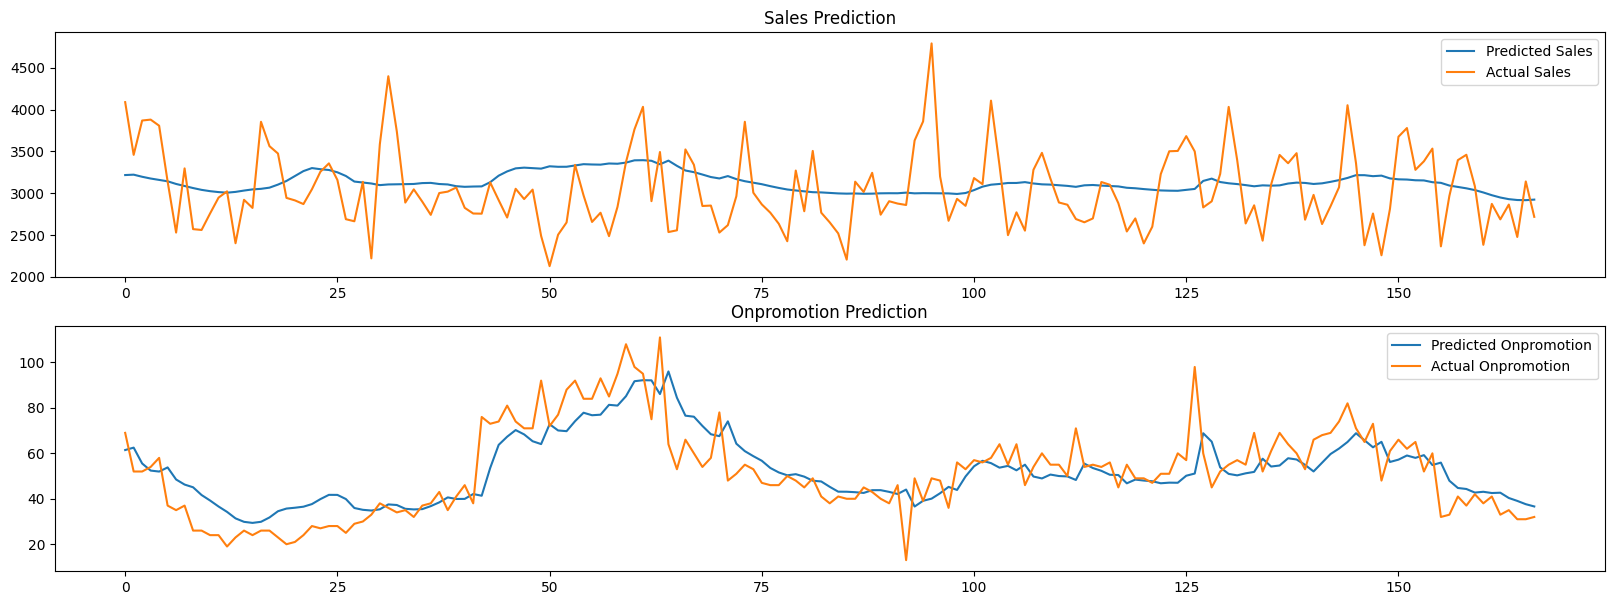

In [94]:
# Plot the results
plt.figure(figsize=(20, 7))

# Sales plot
plt.subplot(2, 1, 1)
plt.plot(pd.DataFrame(testPredict[:, 0]), label='Predicted Sales')
plt.plot(pd.DataFrame(testY[:, 0]), label='Actual Sales')
plt.legend(loc='best')
plt.title('Sales Prediction')

# Onpromotion plot
plt.subplot(2, 1, 2)
plt.plot(pd.DataFrame(testPredict[:, 1]), label='Predicted Onpromotion')
plt.plot(pd.DataFrame(testY[:, 1]), label='Actual Onpromotion')
plt.legend(loc='best')
plt.title('Onpromotion Prediction')

plt.show()

In [95]:
# Membuat dictionary dengan hasil evaluasi RMSE untuk masing-masing model
rmse_comparison = {
    "Model": ["Model VARMAX", "Model VARMAX", "Model Single Layer LSTM", "Model Single Layer LSTM", "Model Single Layer LSTM", "Model Single Layer LSTM", "Model Stacked LSTM Using Dropout", "Model Stacked LSTM Using Dropout", "Model Stacked LSTM Using Dropout", "Model Stacked LSTM Using Dropout"],
    "Metric": ["Train VARMAX", "Test VARMAX","Train RMSE (Sales)", "Test RMSE (Sales)", "Test RMSE (Onpromotion)", "Train RMSE (Onpromotion)",
               "Train RMSE (Sales)", "Test RMSE (Sales)", "Test RMSE (Onpromotion)", "Train RMSE (Onpromotion)"],
    "RMSE Value": [
        rmse_sales, rmse_onpromotion, trainScore_sales, testScore_sales, trainScore_onpromotion, testScore_onpromotion,
        trainScore_sales2, testScore_sales2, trainScore_onpromotion2, testScore_onpromotion2
    ]
}

# Membuat DataFrame untuk perbandingan
rmse_df = pd.DataFrame(rmse_comparison)
rmse_df

,Model,Metric,RMSE Value
0,Model VARMAX,Train VARMAX,785.573565
1,Model VARMAX,Test VARMAX,40.858626
2,Model Single Layer LSTM,Train RMSE (Sales),637.720770
3,Model Single Layer LSTM,Test RMSE (Sales),413.369815
4,Model Single Layer LSTM,Test RMSE (Onpromotion),9.344279
5,Model Single Layer LSTM,Train RMSE (Onpromotion),10.588628
6,Model Stacked LSTM Using Dropout,Train RMSE (Sales),651.801677
7,Model Stacked LSTM Using Dropout,Test RMSE (Sales),478.850848
8,Model Stacked LSTM Using Dropout,Test RMSE (Onpromotion),9.047939
9,Model Stacked LSTM Using Dropout,Train RMSE (Onpromotion),11.637974


# Modelling Using Bidirectional LSTM

In [96]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
import time

# Import keras lstm model
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Bidirectional, GRU, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

window = 22

# Stack LSTM architecture
model3 = Sequential()
# Bidirectional LSTM layer with Dropout regularisation
model3.add(Bidirectional(LSTM(units=50), input_shape=(window,5)))
model3.add(Dropout(0.2))
# The output layer
model3.add(Dense(units=50, kernel_initializer='uniform', activation='tanh'))
model3.add(Dense(units=1, kernel_initializer='uniform', activation='linear'))

earlystop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=50)
callbacks_list = [earlystop]

# Compiling the RNN
model3.compile(optimizer='adam',loss='mean_squared_error')

# Fitting to the training set
start = time.time()
history=model3.fit(X_train, y_train, epochs=100, batch_size=35, validation_split=0.05, verbose=1,callbacks=callbacks_list)
print ('compilation time : ', time.time() - start)

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


ValueError: Exception encountered when calling LSTMCell.call().

[1mDimensions must be equal, but are 3 and 5 for '{{node sequential_2_1/bidirectional_1/forward_lstm_4_1/lstm_cell_1/MatMul}} = MatMul[T=DT_FLOAT, grad_a=false, grad_b=false, transpose_a=false, transpose_b=false](sequential_2_1/bidirectional_1/forward_lstm_4_1/strided_slice_2, sequential_2_1/bidirectional_1/forward_lstm_4_1/lstm_cell_1/Cast/ReadVariableOp)' with input shapes: [?,3], [5,200].[0m

Arguments received by LSTMCell.call():
  • inputs=tf.Tensor(shape=(None, 3), dtype=float32)
  • states=('tf.Tensor(shape=(None, 50), dtype=float32)', 'tf.Tensor(shape=(None, 50), dtype=float32)')
  • training=True

In [ ]:
%matplotlib inline
losses = pd.DataFrame(history3.history)
losses.plot()

NameError: name 'history2' is not defined

In [ ]:
trainPredict = model3.predict(X_train)
testPredict = model3.predict(X_test)

trainPredict = y_scaler.inverse_transform(trainPredict)
trainY = y_scaler.inverse_transform([y_train])
testPredict = y_scaler.inverse_transform(testPredict)
testY = y_scaler.inverse_transform([y_test])

plot_predicted = testPredict.copy()
plot_predicted = plot_predicted.reshape(174, 1)
plot_actual = testY.copy()
plot_actual = plot_actual.reshape(174, 1)
print(plot_actual.shape)
print(plot_predicted.shape)

In [ ]:
trainScore = mean_squared_error(trainY[0], trainPredict[:,0]) ** .5
print('Train Score: %.2f RMSE' % (trainScore))
testScore = mean_squared_error(testY[0], testPredict[:,0]) ** .5
print('Test Score: %.2f RMSE' % (testScore))

In [ ]:
plt.figure(figsize=(20,7))
plot_x = pd.to_datetime(plot_x.iloc[-174:])
plt.plot(pd.DataFrame(plot_predicted), label='Predicted')
plt.plot(pd.DataFrame(plot_actual), label='Actual')
plt.legend(loc='best')
plt.show()

# Model 4 - GRU

In [ ]:
# Stack LSTM architecture
model4 = Sequential()
# GRU layer with Dropout regularisation
model4.add(GRU(units=50, input_shape=(window,5)))
model4.add(Dropout(0.2))

# The output layer
model4.add(Dense(units=50, kernel_initializer='uniform', activation='tanh'))
model4.add(Dense(units=1, kernel_initializer='uniform', activation='linear'))

earlystop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=50)
callbacks_list = [earlystop]

# Compiling the RNN
model4.compile(optimizer='adam',loss='mean_squared_error')
# Fitting to the training set
start = time.time()
history4=model4.fit(X_train,y_train,epochs=100,batch_size=35, validation_split=0.05, verbose=1,callbacks=callbacks_list)
print ('compilation time : ', time.time() - start)

In [ ]:
%matplotlib inline
losses = pd.DataFrame(history4.history)
losses.plot()

In [ ]:
trainPredict = model4.predict(X_train)
testPredict = model4.predict(X_test)

trainPredict = y_scaler.inverse_transform(trainPredict)
trainY = y_scaler.inverse_transform([y_train])
testPredict = y_scaler.inverse_transform(testPredict)
testY = y_scaler.inverse_transform([y_test])

plot_predicted = testPredict.copy()
plot_predicted = plot_predicted.reshape(174, 1)
plot_actual = testY.copy()
plot_actual = plot_actual.reshape(174, 1)
print(plot_actual.shape)
print(plot_predicted.shape)

In [ ]:
trainScore = mean_squared_error(trainY[0], trainPredict[:,0]) ** .5
print('Train Score: %.2f RMSE' % (trainScore))
testScore = mean_squared_error(testY[0], testPredict[:,0]) ** .5
print('Test Score: %.2f RMSE' % (testScore))

In [ ]:
plt.figure(figsize=(20,7))
plot_x = pd.to_datetime(plot_x.iloc[-174:])
plt.plot(pd.DataFrame(plot_predicted), label='Predicted')
plt.plot(pd.DataFrame(plot_actual), label='Actual')
plt.legend(loc='best')
plt.show()

# Model 5 - LSTM using BatchNormalization and Regularization L1 & L2

In [ ]:
# LSTM using BatchNormalization and Regularization (L1 and L2)
#LSTM architecture
model5 = Sequential()
# First LSTM layer with Dropout regularisation
model5.add(LSTM(units=50, input_shape=(window,5),kernel_regularizer='l2'))
model5.add(BatchNormalization())
model5.add(Dropout(0.2))

# The output layer
model5.add(Dense(units=50, kernel_initializer='uniform', activation='tanh'))
model5.add(Dense(units=1, kernel_initializer='uniform', activation='linear'))


# Compiling the RNN
model5.compile(optimizer='adam',loss='mean_squared_error')
# Fitting to the training set
start = time.time()
history5=model5.fit(X_train,y_train,epochs=100,batch_size=35, validation_split=0.05, verbose=1)
print ('compilation time : ', time.time() - start)

In [ ]:
%matplotlib inline
losses = pd.DataFrame(history5.history)
losses.plot()

In [ ]:
trainPredict = model5.predict(X_train)
testPredict = model5.predict(X_test)

trainPredict = y_scaler.inverse_transform(trainPredict)
trainY = y_scaler.inverse_transform([y_train])
testPredict = y_scaler.inverse_transform(testPredict)
testY = y_scaler.inverse_transform([y_test])

plot_predicted = testPredict.copy()
plot_predicted = plot_predicted.reshape(174, 1)
plot_actual = testY.copy()
plot_actual = plot_actual.reshape(174, 1)
print(plot_actual.shape)
print(plot_predicted.shape)

In [ ]:
trainScore = mean_squared_error(trainY[0], trainPredict[:,0]) ** .5
print('Train Score: %.2f RMSE' % (trainScore))
testScore = mean_squared_error(testY[0], testPredict[:,0]) ** .5
print('Test Score: %.2f RMSE' % (testScore))

In [ ]:
plt.figure(figsize=(20,7))
plot_x = pd.to_datetime(plot_x.iloc[-174:])
plt.plot(pd.DataFrame(plot_predicted), label='Predicted')
plt.plot(pd.DataFrame(plot_actual), label='Actual')
plt.legend(loc='best')
plt.show()

# Perbandingan Model

In [ ]:
model = [model1, model2, model3, model4, model5]
history = [history1, history2, history3, history4, history5]
trainScore = []
testScore = []

for i in range(5):
    trainPredict = model[i].predict(X_train)
    testPredict = model[i].predict(X_test)

    trainPredict = y_scaler.inverse_transform(trainPredict)
    trainY = y_scaler.inverse_transform([y_train])
    testPredict = y_scaler.inverse_transform(testPredict)
    testY = y_scaler.inverse_transform([y_test])

    trainScore.append(mean_squared_error(trainY[0], trainPredict[:,0]) ** .5)
    testScore.append(mean_squared_error(testY[0], testPredict[:,0]) ** .5)

    print('Model', i+1)
    print('Train Score: %.2f RMSE' % (trainScore[i]))
    print('Test Score: %.2f RMSE' % (testScore[i]))
    print('\n')

In [ ]:
# Make trainscore and testscore to dataframe
name_of_model = ['LSTM', 'Stacked LSTM', 'Bidirectional LSTM', 'GRU', 'LSTM with BatchNormalization and Regularization']
df_score = pd.DataFrame({'Model':name_of_model,'Train Score': trainScore, 'Test Score': testScore})
df_score

In [ ]:
# Plot the result with bar chart
plt.figure(figsize=(15, 5))
plt.bar(df_score['Model'], df_score['Train Score'], label='Train Score')
plt.bar(df_score['Model'], df_score['Test Score'], label='Test Score')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.title('Train and Test Score of Each Model')
plt.legend(loc='best')
plt.show()

In [ ]:
model4.save('./Final_model.h5')